# Phase 1: Download data

In [18]:
# One-time running code to load dataset and check its structure
from datasets import load_dataset

ds = load_dataset("pietrolesci/eurlex-57k", "default")

labels_meta = load_dataset("pietrolesci/eurlex-57k", "eurovoc_concepts")




In [19]:
# Save ds['train'] anđ ds['test'] to csv for EDA

import pandas as pd
import os

os.makedirs('data/eurlex', exist_ok=True)

ds['train'].to_csv('data/eurlex/train.csv', index=False)
ds['test'].to_csv('data/eurlex/test.csv', index=False)

Creating CSV from Arrow format:   0%|          | 0/45 [00:00<?, ?ba/s]

Creating CSV from Arrow format:   0%|          | 0/6 [00:00<?, ?ba/s]

35565626

In [28]:
labels_meta['train'].to_csv('data/eurlex/train_labels.csv', index=False)

Creating CSV from Arrow format:   0%|          | 0/8 [00:00<?, ?ba/s]

169074

# Phase 2: EDA

## I. Data Exploring

### 1. Fields and features

In [1]:
import pandas as pd
train_df = pd.read_csv('data/eurlex/train.csv')
test_df = pd.read_csv('data/eurlex/test.csv')
label_df = pd.read_csv('data/eurlex/train_labels.csv')

In [154]:
print(train_df.head(1)) 
print("======================== Dataset Information ========================")
print(train_df.info())

     celex_id document_type  \
0  32014R0727    Regulation   

                                               title  \
0  Commission Implementing Regulation (EU) No 727...   

                                              header  \
0  1.7.2014 EN Official Journal of the European U...   

                                            recitals  \
0  ,\nHaving regard to the Treaty on the Function...   

                                           main_body  \
0  ["A review of Implementing Regulation (EU) No ...   

                                    eurovoc_concepts  \
0  ['1402' '2771' '3191' '5055' '519' '5969' '5971']   

                                                text  uid  
0  Commission Implementing Regulation (EU) No 727...    0  
======================== Dataset Information ========================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            -----

In [63]:
print(test_df.head(1)) 
print(test_df.info())

     celex_id document_type  \
0  32011D0690      Decision   

                                               title  \
0  Commission Implementing Decision of 14 October...   

                                              header  \
0  15.10.2011 EN Official Journal of the European...   

                                            recitals  \
0  ,\nHaving regard to the Treaty on the Function...   

                                           main_body  \
0  ['The Annex to Decision 2011/163/EU is replace...   

                                    eurovoc_concepts  \
0  ['1166' '1338' '1445' '1644' '1729' '1841' '19...   

                                                text    uid  
0  Commission Implementing Decision of 14 October...  45000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   celex_id          6000 non-null   object
 1  

### 2. Frequency and distribution

In [21]:

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
import numpy as np
import re

def clean_tags(tags):
    if isinstance(tags, str):
        clean_s = re.sub(r'[^a-zA-Z0-9\s_]', '', tags)
        return [tag.strip() for tag in clean_s.split() if tag.strip()]    
    elif isinstance(tags, list):
        return tags
    else:
        print(f"Unexpected tags format: {tags}")
        return []
    
def eda(df, out_dir='result/eurlex', top = 10):
    os.makedirs(out_dir, exist_ok=True)
    df= df.copy()
    
    df['t_len'] = df['text'].apply(lambda x: len(str(x).split()))
    df['til_len'] = df['title'].apply(lambda x: len(str(x).split()))
    df['r_len'] = df['recitals'].apply(lambda x: len(str(x).split()))
    df['h_len'] = df['header'].apply(lambda x: len(str(x).split()))
    df["m_len"] = df['main_body'].apply(lambda x: len(str(x).split()))


    df['tags'] = df['eurovoc_concepts'].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
    
    all_labels = []
    df['tags'].apply(lambda x: all_labels.extend(clean_tags(x)))
    df['tags_count'] = df['tags'].apply(lambda x: len(clean_tags(x)))
    
    print("\n" + "="*20 + " DATASET STATS " + "="*20)
    print(df[['t_len','til_len','r_len','h_len','m_len','tags_count']].describe())

    label_counts = Counter(all_labels)
    unique_labels = len(label_counts)
    counts = np.array(list(label_counts.values()))

    frequent = np.sum(counts > 50)
    few_shot = np.sum((counts <= 50) & (counts >= 1))
    
    print(f"\nUnique labels found in data: {unique_labels}")
    print(f"--> Frequent labels (>50 samples): {frequent}")
    print(f"--> Few-shot labels (1-50 samples): {few_shot}")
    print(f"Top {top} labels:", label_counts.most_common(top))
    print(f"Bottom {top} labels:", label_counts.most_common()[:-top-1:-1])

    plt.style.use('seaborn-v0_8-muted')
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    sns.histplot(df['t_len'], bins=50, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title('Text Length Distribution (Words)')
    axes[0].axvline(512, color='red', linestyle='--', label='MiniLM Limit (approx)')
    axes[0].legend()

    sns.histplot(df['tags_count'], bins=range(min(df['tags_count']), max(df['tags_count']) + 2), 
                 kde=False, ax=axes[1], color='salmon')
    axes[1].set_title('Labels per Document Distribution')
    

    plt.tight_layout()

    os.makedirs(out_dir, exist_ok=True)

    plt.savefig(f'{out_dir}/data_dist.png')
    plt.show()

    sorted_counts = sorted(counts, reverse=True)
    plt.figure(figsize=(10, 5))
    plt.plot(sorted_counts, color='purple', linewidth=2)
    plt.fill_between(range(len(sorted_counts)), sorted_counts, color='purple', alpha=0.2)
    plt.yscale('log')
    plt.title('Label Frequency (Log Scale) - The Long Tail')
    plt.xlabel('Label Rank')
    plt.ylabel('Number of Samples')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.savefig(f'{out_dir}/long_tail.png')
    plt.show()

    return label_counts, df


==================== DATASET STATS ====================
              t_len       til_len         r_len         h_len         m_len  \
count  45000.000000  45000.000000  45000.000000  45000.000000  45000.000000   
mean     351.190756     33.190511    318.000289     43.197267    182.097844   
std      264.931432     11.762600    263.049528     14.107924    256.703634   
min       15.000000      1.000000      1.000000      7.000000      5.000000   
25%      202.000000     25.000000    169.000000     34.000000     57.000000   
50%      273.000000     31.000000    237.000000     41.000000     87.000000   
75%      399.000000     39.000000    364.000000     50.000000    175.000000   
max     3236.000000    206.000000   3208.000000    480.000000   2572.000000   

         tags_count  
count  45000.000000  
mean       5.073822  
std        1.698455  
min        1.000000  
25%        4.000000  
50%        5.000000  
75%        6.000000  
max       26.000000  

Unique labels found in data: 410

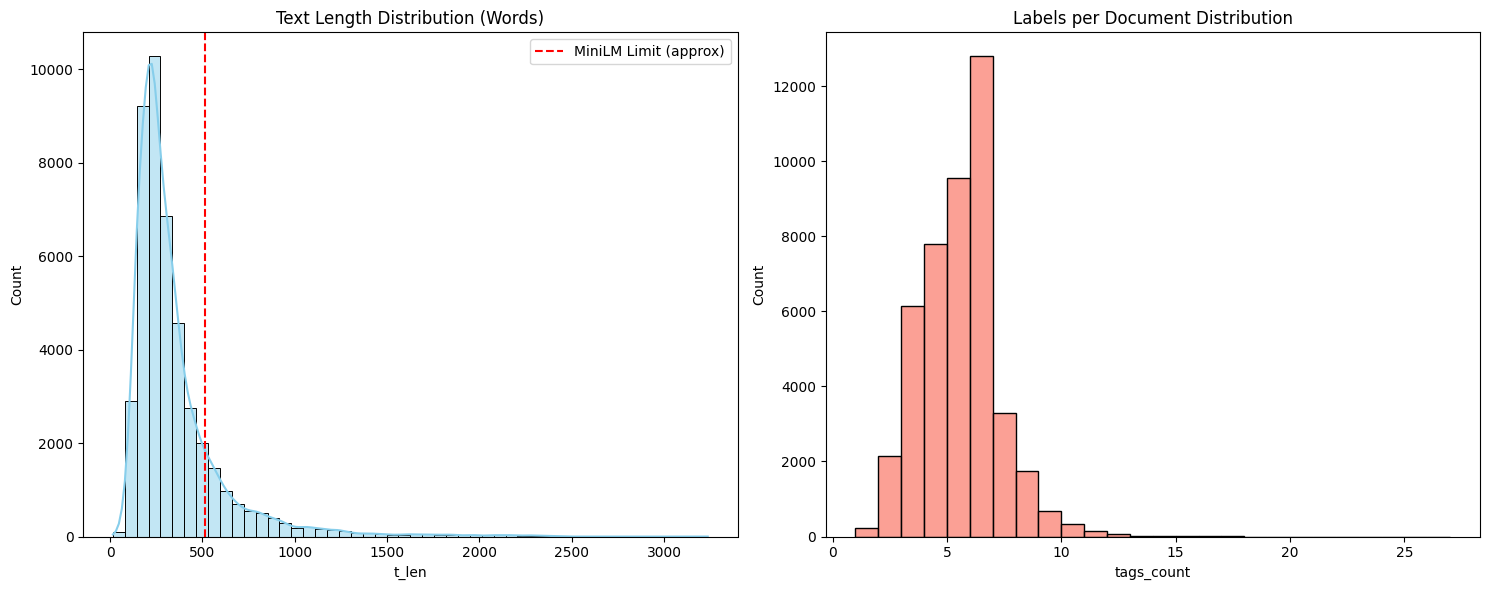

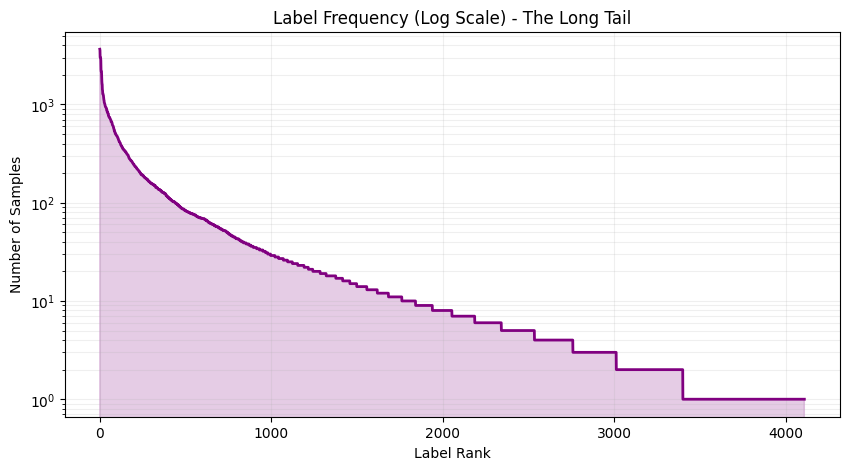

In [3]:
train_labels, train_df = eda(train_df, "result/eurlex/train")


==================== DATASET STATS ====================
             t_len     til_len        r_len        h_len        m_len  \
count  6000.000000  6000.00000  6000.000000  6000.000000  6000.000000   
mean    350.362167    32.91850   317.443667    43.025500   175.362833   
std     264.542515    11.39742   262.835564    13.670552   246.099719   
min      43.000000     1.00000    18.000000    10.000000     5.000000   
25%     202.000000    24.00000   169.000000    34.000000    56.000000   
50%     274.000000    31.00000   237.000000    41.000000    85.000000   
75%     395.000000    39.00000   360.000000    50.000000   167.250000   
max    2443.000000   147.00000  2418.000000   311.000000  2384.000000   

        tags_count  
count  6000.000000  
mean      5.059333  
std       1.736754  
min       1.000000  
25%       4.000000  
50%       5.000000  
75%       6.000000  
max      19.000000  

Unique labels found in data: 2517
--> Frequent labels (>50 samples): 132
--> Few-shot labels (1

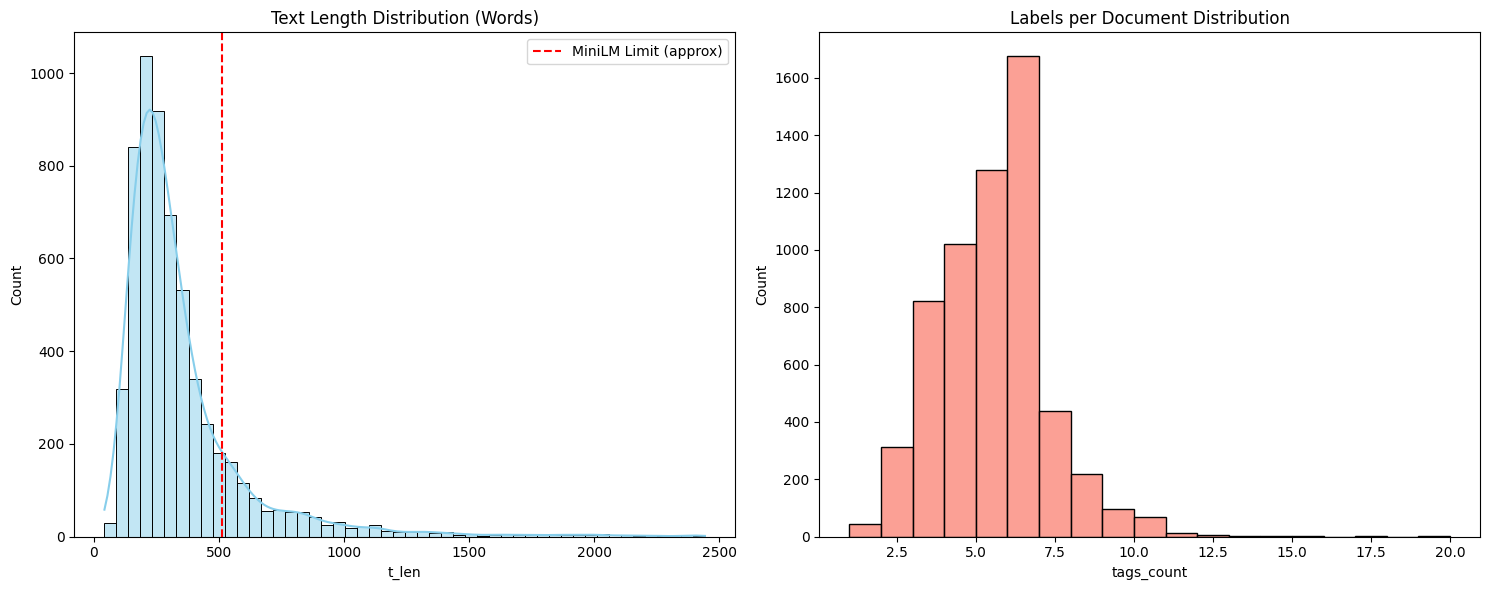

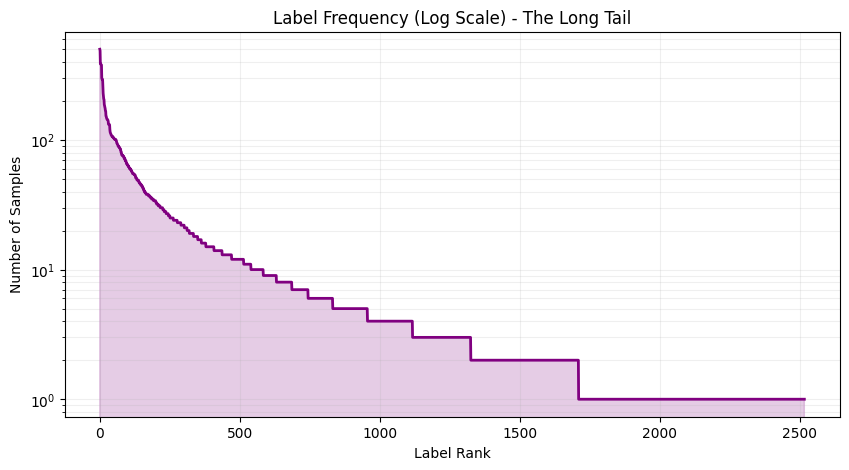

In [4]:
test_labels, test_df = eda(test_df, "result/eurlex/test")

In [5]:
def check_unseen_labels(train : Counter, test : Counter, thresh = 50):
    all_test_labels = list(test.keys())
    
    analysis = []
    zero_shot = []
    fw = []
    for label in all_test_labels:
        train_freq = train.get(label, 0)
        test_freq = test.get(label, 0)
        
        if train_freq == 0:
            category = "Zero-shot"
            zero_shot.append({"Label": label, "Test_Freq": test_freq})
        elif train_freq < thresh:
            category = "Few-shot"
            fw.append({"Label": label, "Test_Freq": test_freq})

        else:
            category = "Normal"
            
        analysis.append(category)

    summary_counts = Counter(analysis)
    summary_df = pd.DataFrame([
        {"Category": f"Normal (>= {thresh})", "Count": summary_counts.get("Normal", 0)},
        {"Category": f"Few-shot (< {thresh})", "Count": summary_counts.get("Few-shot", 0)},
        {"Category": "Zero-shot (Unseen)", "Count": summary_counts.get("Zero-shot", 0)}
    ])

    zs_df = pd.DataFrame(zero_shot).sort_values(by="Test_Freq", ascending=False)
    fw_df = pd.DataFrame(fw).sort_values(by="Test_Freq", ascending=False)

    print("\n" + "="*20 + " LABEL DISTRIBUTION SUMMARY " + "="*20)
    print(summary_df.to_markdown(index=False)) 
    print("\n" + "="*20 + " ZERO-SHOT SAMPLES IN TEST " + "="*20)
    
    if not zs_df.empty:
        print(f"Total Zero-shot labels: {len(zs_df)}")
        print(zs_df.head(10).to_string(index=False))
    else:
        print("No Zero-shot labels found!")

    return summary_df, zs_df, fw_df



In [6]:
summary_df, zs_df, fw_df = check_unseen_labels(train_labels, test_labels)


==================== LABEL DISTRIBUTION SUMMARY ====================
| Category           |   Count |
|:-------------------|--------:|
| Normal (>= 50)     |     746 |
| Few-shot (< 50)    |    1686 |
| Zero-shot (Unseen) |      85 |

==================== ZERO-SHOT SAMPLES IN TEST ====================
Total Zero-shot labels: 85
Label  Test_Freq
 2162          3
 2175          2
  957          2
  716          2
 5110          2
 6913          2
 2382          2
 1113          2
 1588          2
 3792          2


In [162]:
train_df.to_csv('data/eurlex/train.csv', index=False)
test_df.to_csv('data/eurlex/test.csv', index=False)

### 2. Correlations, visualizing tags relation

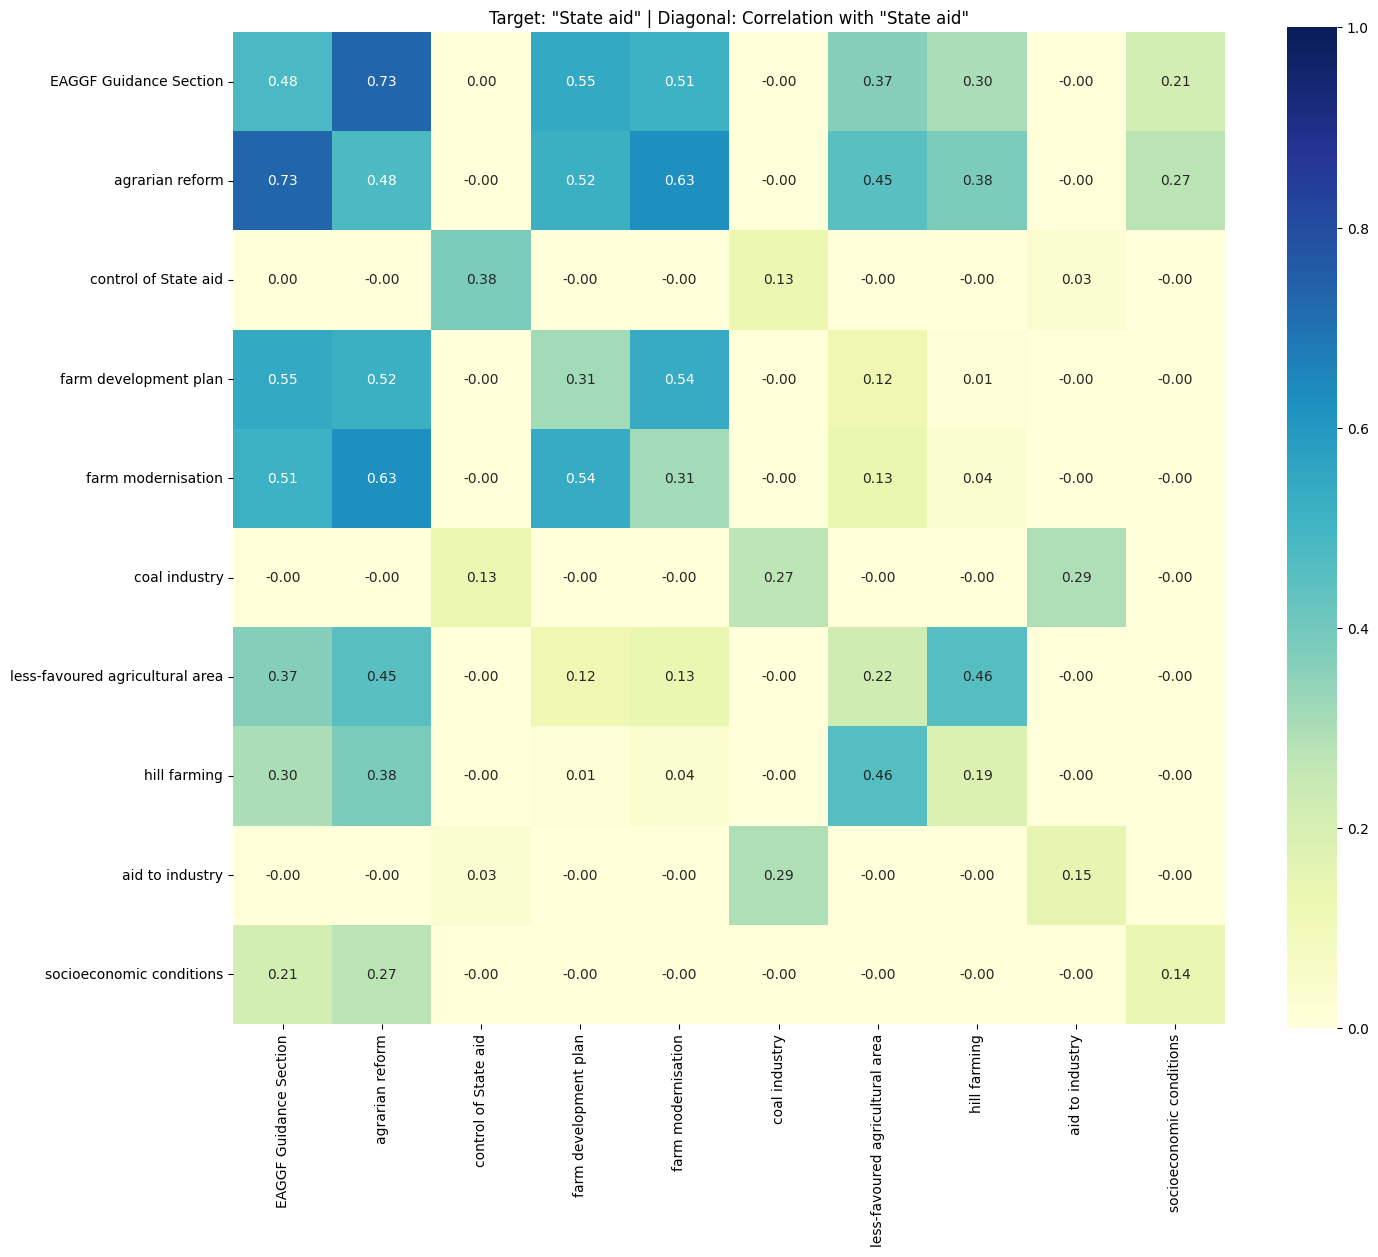

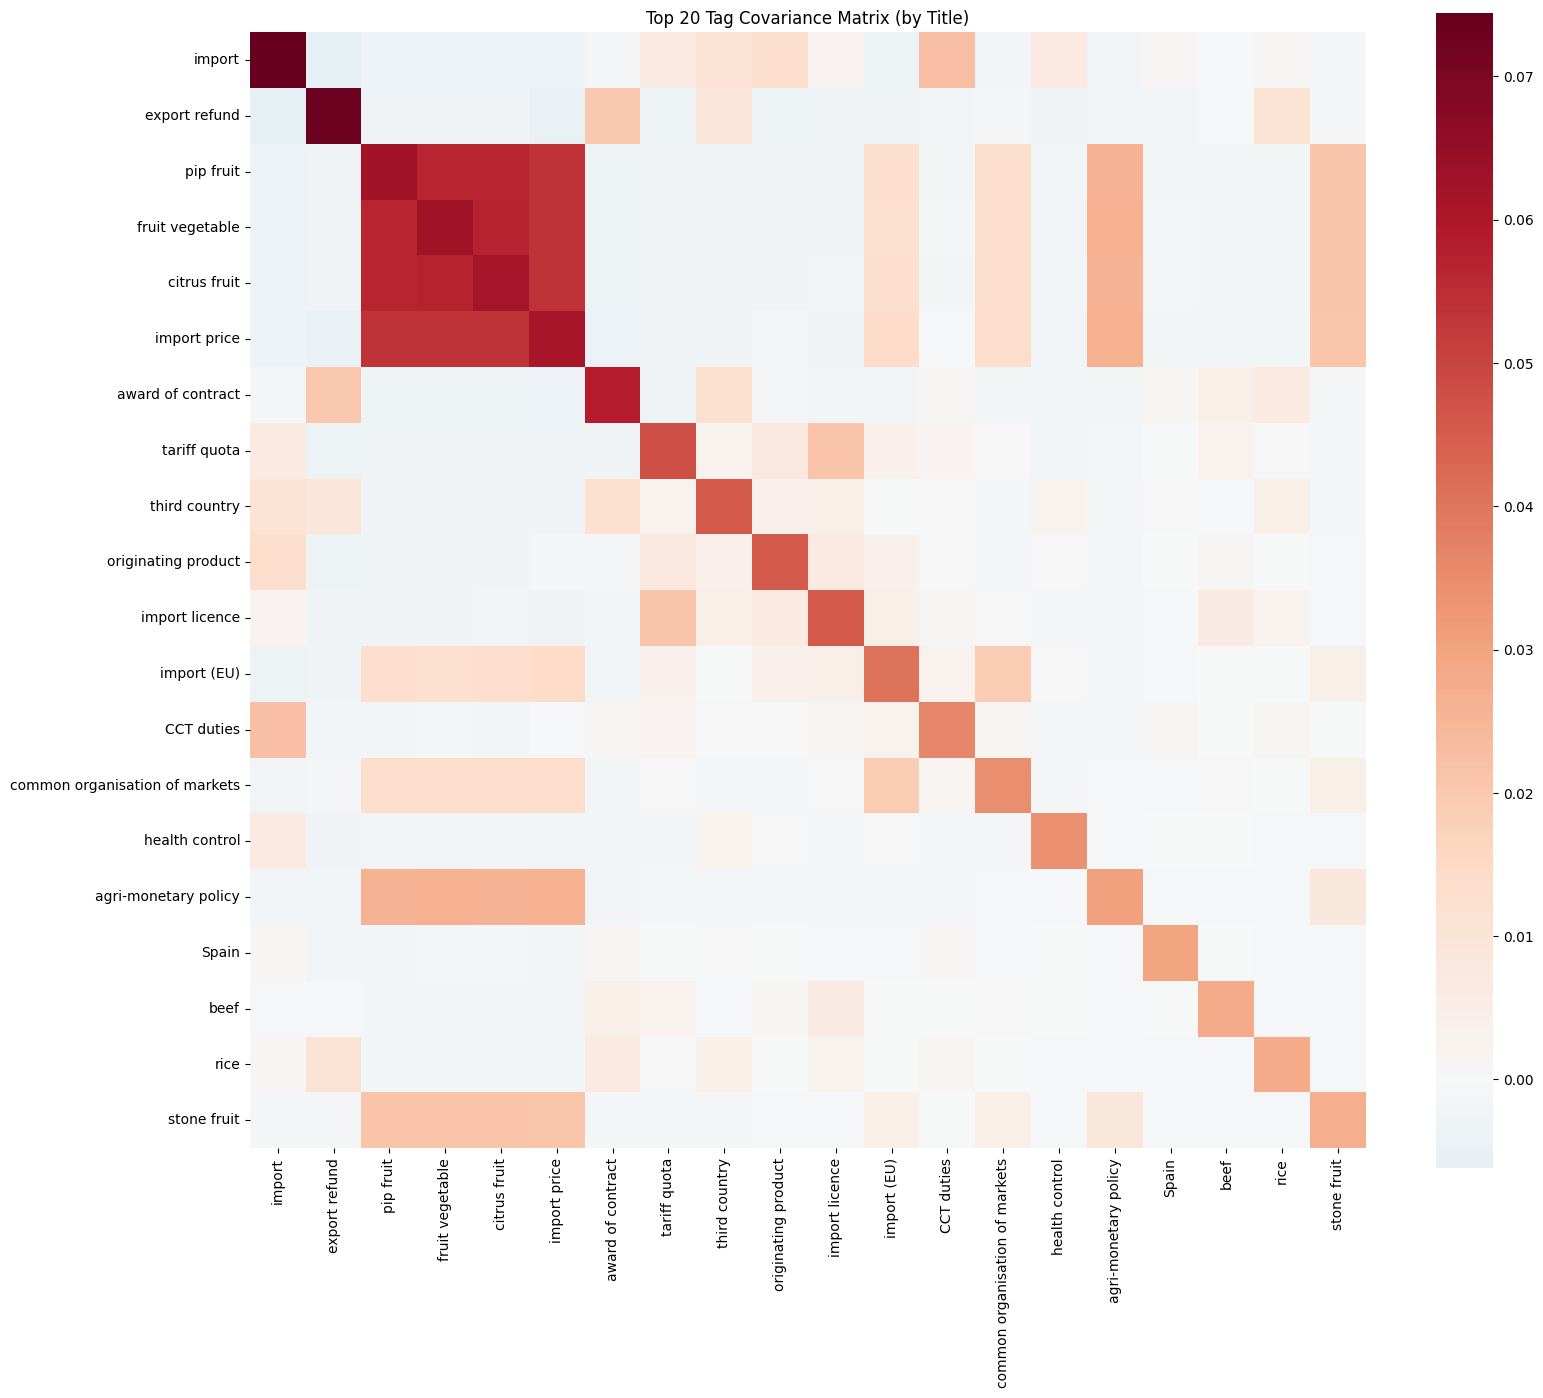

In [16]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer

def plot_tag(m, u_tags, target="889", top=5, mapper=None, out='result/eurlex/cov_matrix.png'):
    if target not in u_tags: return print(f"Tag {target} not found")
    
    # Tạo dict tra cứu nhanh: id -> title
    id_to_title = dict(zip(mapper['concept_id'].astype(str), mapper['title'])) if mapper is not None else {}
    
    v = np.sqrt(np.diag(m))
    v[v == 0] = 1e-9
    corr_m = m / np.outer(v, v)
    
    t2i = {t: i for i, t in enumerate(u_tags)}
    tid = t2i[target]
    
    row = corr_m[tid]
    idx = np.argsort(row)[::-1]
    rel_idx = idx[idx != tid][:top]
    
    sub_m = corr_m[np.ix_(rel_idx, rel_idx)].copy()
    
    # Map ID sang Title cho các nhãn trục
    t_sub = [id_to_title.get(str(u_tags[i]), str(u_tags[i])) for i in rel_idx]
    
    for i, idx_val in enumerate(rel_idx):
        sub_m[i, i] = corr_m[idx_val, tid]
        
    plt.figure(figsize=(16, 13))
    sns.heatmap(sub_m, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, 
                xticklabels=t_sub, yticklabels=t_sub, square=True)
    
    target_name = id_to_title.get(str(target), str(target))
    plt.title(f'Target: "{target_name}" | Diagonal: Correlation with "{target_name}"')
    
    os.makedirs(os.path.dirname(out), exist_ok=True)
    plt.savefig(out)
    plt.show()
    plt.close()

def plot_co(cov_m, u_tags, mapper=None, top_n=30, out='result/eurlex/co_matrix.png'):
    id_to_title = dict(zip(mapper['concept_id'].astype(str), mapper['title'])) if mapper is not None else {}
    
    idx = np.argsort(np.diag(cov_m))[::-1][:top_n]
    m_sub = cov_m[np.ix_(idx, idx)]
    
    # Map ID sang Title cho toàn bộ ma trận top_n
    t_sub = [id_to_title.get(str(u_tags[i]), str(u_tags[i])) for i in idx]
    
    plt.figure(figsize=(18, 15)) # Tăng size một chút vì Title thường dài hơn ID
    sns.heatmap(m_sub, annot=False, cmap='RdBu_r', center=0, 
                xticklabels=t_sub, yticklabels=t_sub, square=True)
    plt.title(f'Top {top_n} Tag Covariance Matrix (by Title)')

    os.makedirs(os.path.dirname(out), exist_ok=True)
    plt.savefig(out)
    plt.show()

def get_cov_matrix(df, mapper, plot=True):
    # Đảm bảo clean_tags trả về list
    tag_lists = df['tags'].apply(clean_tags)
    mlb = MultiLabelBinarizer(sparse_output=True)
    X = mlb.fit_transform(tag_lists)
    u_tags = mlb.classes_
    
    n = X.shape[0]
    sum_x = np.array(X.sum(axis=0)).flatten()
    dot_product = (X.T @ X).toarray() 
    
    cov_m = (dot_product / (n - 1)) - np.outer(sum_x, sum_x) / (n * (n - 1))
    
    if plot:
        # Vẽ cả 2 loại để check
        plot_tag(cov_m, u_tags, mapper=mapper, target="889", top=10, out='result/eurlex/tag_889_cov.png')
        plot_co(cov_m, u_tags, mapper=mapper, top_n=20)
        
    return cov_m, u_tags

m, u_tags = get_cov_matrix(train_df, label_df)

### 3. Clustering tags, forming community

In [8]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

def get_subsumption(df, threshold=0.6):
    tag_lists = df['tags'].apply(clean_tags)
    mlb = MultiLabelBinarizer(sparse_output=True)
    X = mlb.fit_transform(tag_lists)
    u_tags = mlb.classes_
    
    counts = np.array(X.sum(axis=0)).flatten()
    co_matrix = (X.T @ X).toarray()
    
    prob_matrix = co_matrix / counts
    
    hierarchy = []
    for i, tag_b in enumerate(u_tags):
        for j, tag_a in enumerate(u_tags):
            if i != j and prob_matrix[j, i] >= threshold:
                if prob_matrix[i, j] < prob_matrix[j, i]:
                    hierarchy.append({'child': tag_b, 'parent': tag_a, 'conf': prob_matrix[j, i]})
                    
    return pd.DataFrame(hierarchy), co_matrix, u_tags

def get_communities(co_matrix, u_tags, min_weight=3):
    G = nx.Graph()
    for i in range(len(u_tags)):
        for j in range(i + 1, len(u_tags)):
            if co_matrix[i, j] >= min_weight:
                G.add_edge(u_tags[i], u_tags[j], weight=co_matrix[i, j])
    
    partition = community_louvain.best_partition(G, weight='weight')
    return partition

def analyze_hierarchy(df):
    sub_df, co_m, tags = get_subsumption(df)
    comm_map = get_communities(co_m, tags)
    
    res = []
    for tag in tags:
        res.append({
            'tag': tag,
            'community': comm_map.get(tag, -1),
            'is_root': tag in sub_df['parent'].values,
            'parent_candidate': sub_df[sub_df['child'] == tag]['parent'].tolist()[:3]
        })
        
    roots = sub_df.groupby('parent').size().sort_values(ascending=False)
    return pd.DataFrame(res), roots



In [9]:
res_df, root_stats = analyze_hierarchy(train_df)
print("--- Root Tags ---")
print(root_stats.head(5))
print("\n--- Sample Hierarchy ---")
print(res_df[res_df['is_root'] == False].head(10))

--- Root Tags ---
parent
4381    60
3483    55
2771    52
1091    46
889     41
dtype: int64

--- Sample Hierarchy ---
     tag  community  is_root    parent_candidate
0     10         -1    False                  []
2   1002         -1    False                  []
3   1004          4    False  [3357, 4667, 4860]
5   1006          8    False  [1119, 1182, 1608]
6   1007         12    False                  []
7   1008          0    False                  []
15  1024         -1    False   [1414, 2312, 616]
16  1025          4    False                  []
17  1026          7    False  [1048, 2300, 4271]
18  1027         -1    False  [1005, 1052, 2518]


In [11]:
print(f"{len(res_df[res_df['community'] == -1])}/{len(res_df)} tags are not assigned to any community")

1577/4108 tags are not assigned to any community


In [ ]:
from sklearn.cluster import AgglomerativeClustering

def get_rep_tags(m, u_tags, labels):
    unique_labels = np.unique(labels)
    rep_mapping = {}
    v = np.sqrt(np.diag(m))
    v[v == 0] = 1e-9
    corr_m = m / np.outer(v, v)
    for label in unique_labels:
        idx = np.where(labels == label)[0]
        if len(idx) == 0: continue
        sub_corr = corr_m[np.ix_(idx, idx)]
        centrality = sub_corr.sum(axis=1)
        best_idx = idx[np.argmax(centrality)]
        rep_mapping[label] = u_tags[best_idx]
    return rep_mapping

def analyze_clusters_hybrid(df, min_weight=1):
    sub_df, co_m, u_tags = get_subsumption(df)
    
    G = nx.Graph()
    G.add_nodes_from(u_tags)
    for i in range(len(u_tags)):
        for j in range(i + 1, len(u_tags)):
            if co_m[i, j] >= min_weight:
                G.add_edge(u_tags[i], u_tags[j], weight=co_m[i, j])
    
    partition = community_louvain.best_partition(G, weight='weight')
    
    v = np.sqrt(np.diag(co_m))
    v[v == 0] = 1e-9
    corr_m = co_m / np.outer(v, v)
    
    unique_comms = set(partition.values())
    louvain_rep_map = {}
    for c_id in unique_comms:
        idx = [i for i, t in enumerate(u_tags) if partition.get(t) == c_id]
        if not idx: continue
        sub_corr = corr_m[np.ix_(idx, idx)]
        louvain_rep_map[c_id] = u_tags[idx[np.argmax(sub_corr.sum(axis=1))]]

    cluster_counts = pd.Series(partition.values()).value_counts()
    k_opt = len(cluster_counts[cluster_counts > 1])
    if k_opt < 2: k_opt = 30
        
    dist_m = 1 - np.clip(corr_m, 0, 1)
    ac = AgglomerativeClustering(n_clusters=k_opt, metric='precomputed', linkage='average')
    ac_labels = ac.fit_predict(dist_m)
    
    ac_rep_map = get_rep_tags(co_m, u_tags, ac_labels)
    
    res_list = []
    for i, tag in enumerate(u_tags):
        l_id = partition.get(tag)
        a_id = ac_labels[i]
        res_list.append({
            'tag': tag,
            'ac_id': a_id,
            'ac_name': ac_rep_map.get(a_id),
            'louvain_id': l_id,
            'louvain_name': louvain_rep_map.get(l_id, "Isolated"),
            'is_root': tag in sub_df['parent'].values
        })
        
    res_df = pd.DataFrame(res_list)
    
    summary = res_df.groupby(['louvain_id', 'louvain_name']).size().reset_index(name='tag_count')
    summary = summary.sort_values('tag_count', ascending=False).reset_index(drop=True)
    
    return res_df, summary

In [164]:
res_df, detected_k = analyze_clusters_hybrid(train_df)

In [106]:
print("--- Cluster Analysis ---")
print(f"Detected Clusters: {detected_k.shape[0]}")
print(detected_k)


--- Cluster Analysis ---
Detected Clusters: 11
    louvain_id louvain_name  tag_count
0            0         4258       1259
1            6         3483        951
2           10         3516        680
3            8         2771        367
4            3         1445        270
5            7         5451        224
6            2           20        207
7            9         2879        113
8            4         4645         23
9            1          693         13
10           5         3664          1


In [108]:
print(len(res_df[res_df['louvain_name'] == "4258"]))
print(len(res_df[res_df['ac_name'] == "4258"]))

1259
0


In [2]:
train_df.head(1)

,celex_id,document_type,title,header,recitals,main_body,eurovoc_concepts,text,uid,t_len,tags,tags_count
0,32014R0727,Regulation,Commission Implementing Regulation (EU) No 727...,1.7.2014 EN Official Journal of the European U...,",\nHaving regard to the Treaty on the Function...","[""A review of Implementing Regulation (EU) No ...",['1402' '2771' '3191' '5055' '519' '5969' '5971'],Commission Implementing Regulation (EU) No 727...,0,1783,"['1402', '2771', '3191', '5055', '519', '5969'...",7


## II. Preprocess whole data, put it all togeter

In [31]:
import re
import unicodedata
import ast
import pandas as pd

def clean_legal(text):

    if not text or pd.isna(text):
        return ""
    # String list from recitals or main_body
    if isinstance(text, str) and text.startswith('['):
        try:
            items = ast.literal_eval(text)
            text = " ".join(items) if isinstance(items, list) else str(items)
        except (ValueError, SyntaxError):
            pass

    text = str(text)
    
    # Strip HTML tags (If yes)
    text = re.sub(r'<.*?>', ' ', text)
    
    # 3. Unicode Normalization (NFC)
    text = unicodedata.normalize('NFC', text)
    
    # 4. Remove Footnotes [1], [2] or (1), (2)

    text = re.sub(r'\[\s*\d+\s*\]', ' ', text)
    text = re.sub(r'\(\s*\d+\s*\)', ' ', text)
    
    # 5. Normalize special punctuation
    text = text.replace('–', '-').replace('—', '-').replace('“', '"').replace('”', '"')
    

    text = re.sub(r'\s+', ' ', text).strip()
    
    # Lowercase 
    return text.lower()

In [43]:
from typing import Union
import os
import re

def filter_tags(df, ratio=0.001, filter=None):
    N = len(df)
    if ratio:
        threshold = int(N * ratio)
        
        all_tags = [t.strip() for tags in df['tags'] for t in (tags if isinstance(tags, list) else str(tags).split('|'))]
        tag_counts = pd.Series(all_tags).value_counts()
        valid_tags = set(tag_counts[tag_counts >= threshold].index)
        print(f"--- FLAT BASELINE SETUP (Ratio: {ratio}) ---")
        print(f"Calculated Threshold: {threshold} samples")
        print(f"Unique Tags Remaining: {len(valid_tags)} (Dropped {len(tag_counts) - len(valid_tags)})")
        print(f"Samples Maintained: {len(df)} / {N}")
    elif filter is not None:    
        valid_tags = filter
    else:
        df['filtered_tags'] = df['tags']
        all_tags = [t.strip() for tags in df['tags'] for t in (tags if isinstance(tags, list) else str(tags).split('|'))]
        tag_counts = pd.Series(all_tags).value_counts()
        valid_tags = set(tag_counts[tag_counts > 0].index)
        
        return df, sorted(list(valid_tags))
        
    def clean_func(tags):
            t_list = tags if isinstance(tags, list) else str(tags).split('|')
            return [t.strip() for t in t_list if t.strip() in valid_tags]
    
    df['filtered_tags'] = df['tags'].apply(clean_func)
    

    df = df[df['filtered_tags'].map(len) > 0].copy()
    
    
    
    return df, sorted(list(valid_tags))

def get_comm(df):
    sub_df, co_m, u_tags = get_subsumption(df)
    partition = get_communities(co_m, u_tags, min_weight=5)
    
    v = np.sqrt(np.diag(co_m))
    v[v == 0] = 1e-9
    corr_m = co_m / np.outer(v, v)
    
    unique_ids = set(partition.values())
    rep_names = {}
    for c_id in unique_ids:
        indices = [i for i, t in enumerate(u_tags) if partition.get(t) == c_id]
        if not indices: continue
        sub_corr = corr_m[np.ix_(indices, indices)]
        centrality = sub_corr.sum(axis=1)
        rep_names[c_id] = u_tags[indices[np.argmax(centrality)]]
        
    return partition, rep_names
def get_title(mapper, concept_id):
    title = mapper[mapper["concept_id"] == concept_id]["title"]
    if not title.empty:
            return title
    print(f"Warning: Concept ID {concept_id} not found in mapper.")
    return concept_id

def prep(src, dst=None, mapper=None, ratio=0.001, filter = None):
    if isinstance(src, str):
        df = pd.read_csv(src)
    else:
        df = src.copy()

    df['text'] = df['text'].apply(clean_legal)
    df['main_body'] = df['main_body'].apply(clean_legal)
    df['title'] = df['title'].apply(clean_legal)
    df['recitals'] = df['recitals'].apply(clean_legal)

    if mapper is not None:
        df['tag_names'] = df['tags'].apply(lambda x: get_title(mapper, x))

    if ratio:
        df, val_tags = filter_tags(df, ratio=ratio)
    else:
        df, val_tags = filter_tags(df, ratio=None, filter = filter)
    
    # Get Community Mapping
    mapping, names = get_comm(df)
    
    def map_to_multi_l1(tags):
        l1_ids = {mapping.get(t) for t in tags if mapping.get(t) is not None}
        return sorted(list(l1_ids))

    df['l1'] = df['filtered_tags'].apply(map_to_multi_l1)
    
    df['l1_name'] = df['l1'].apply(lambda ids: [names.get(i) for i in ids])

    if dst:
        if os.path.dirname(dst):
            os.makedirs(os.path.dirname(dst), exist_ok=True)
        df.to_csv(dst, index=False)
        
    return df, mapping, names, val_tags

In [128]:
label_df = label_df.drop_duplicates(subset=['concept_id']).copy()
label_df[label_df["concept_id"] == "3474"].head()
label_df.to_csv('data/eurlex/train_labels.csv', index=False)

In [37]:
train_df, mapper, names, val_tags = prep(train_df, 'data/eurlex/train_processed.csv',label_df,None, None)
test_df, mapper, names, val_tags = prep(test_df, 'data/eurlex/test_processed.csv',label_df,None, None)


In [41]:

mlb = MultiLabelBinarizer()
mlb.fit(train_df['filtered_tags'].apply(clean_tags))
print("Number of classes:", len(mlb.classes_))

print("Sample classes:", mlb.classes_[-10:])


Number of classes: 4108
Sample classes: ['99' '990' '993' '994' '995' '996' '997' '998' '999' 'c_871b5612']


In [ ]:
txt = train_df["text"].iloc[0]
n = len(str(txt))
for i in range(0, n, 150):
    print(txt[i:i + 150])

commission implementing regulation (eu) no 727/2014 of 30 june 2014 initiating a ‘new exporter’ review of council implementing regulation (eu) no 1389
/2011 imposing a definitive anti-dumping duty on imports of trichloroisocyanuric acid originating in the people's republic of china, repealing the dut
y with regard to imports from one exporter in this country and making these imports subject to registration , having regard to the treaty on the funct
ioning of the european union, having regard to council regulation (ec) no 1225/2009 of 30 november 2009 on protection against dumped imports from coun
tries not members of the european community (‘the basic regulation’) and in particular article 11 thereof, after informing the member states, whereas:
 1. request the european commission (‘commission’) has received a request for a ‘new exporter’ review pursuant to article 11 of the basic regulation. 
the request was lodged on 4 january 2014 by juancheng kangtai chemical co. ltd (‘the applicant

In [155]:
title = train_df["title"].iloc[0]
print(f"\nTitle({len(title.split())} words):", title)
print(f"Heading({len(train_df['header'].iloc[0].split())} words):", train_df["header"].iloc[0])
print(f"Recitals({len(train_df['recitals'].iloc[0].split())} words):", train_df["recitals"].iloc[0])
print(f"Main Body({len(train_df['main_body'].iloc[0].split())} words):", train_df["main_body"].iloc[0])


Title(59 words): commission implementing regulation (eu) no 727/2014 of 30 june 2014 initiating a ‘new exporter’ review of council implementing regulation (eu) no 1389/2011 imposing a definitive anti-dumping duty on imports of trichloroisocyanuric acid originating in the people's republic of china, repealing the duty with regard to imports from one exporter in this country and making these imports subject to registration
Heading(72 words): 1.7.2014 EN Official Journal of the European Union L 192/42
COMMISSION IMPLEMENTING REGULATION (EU) No 727/2014
of 30 June 2014
initiating a ‘new exporter’ review of Council Implementing Regulation (EU) No 1389/2011 imposing a definitive anti-dumping duty on imports of trichloroisocyanuric acid originating in the People's Republic of China, repealing the duty with regard to imports from one exporter in this country and making these imports subject to registration
THE EUROPEAN COMMISSION
Recitals(1696 words): , having regard to the treaty on the func

In [113]:
print(mapper)
print(names)

{'10': 0, '11': 1, '2066': 0, '2300': 2, '2527': 0, '2611': 0, '2734': 3, '2803': 4, '2816': 1, '2825': 5, '3636': 1, '4256': 0, '441': 0, '5205': 6, '5237': 0, '5283': 4, '5891': 0, '816': 0, '9': 0, '1000': 6, '1005': 7, '1052': 6, '1074': 1, '1154': 6, '1158': 5, '1163': 1, '1354': 4, '1379': 3, '1462': 6, '1474': 3, '1476': 4, '1519': 5, '1613': 3, '1833': 0, '2084': 8, '2095': 3, '2173': 9, '218': 1, '225': 1, '2296': 3, '2303': 1, '2320': 7, '259': 6, '26': 3, '2610': 7, '2636': 4, '2647': 1, '2718': 7, '2730': 4, '2770': 1, '2792': 7, '287': 6, '2901': 3, '2915': 5, '2938': 4, '2986': 6, '3003': 4, '3075': 6, '3170': 4, '3466': 3, '3483': 1, '3489': 1, '350': 7, '3651': 6, '3885': 5, '392': 7, '4005': 1, '4055': 1, '412': 6, '413': 6, '4284': 4, '4320': 8, '4359': 0, '4373': 4, '4452': 1, '4486': 0, '4502': 0, '4580': 3, '4600': 10, '4682': 4, '4713': 4, '4734': 4, '4860': 4, '500': 4, '5083': 3, '5155': 4, '5181': 0, '5315': 7, '5343': 3, '5350': 7, '5413': 0, '5419': 6, '5462'

In [114]:
for k,v in mapper.items():
    print(f"{k}", end=", ") if v == 5 else None

2825, 1158, 1519, 2915, 3885, 5877, 616, 6411, 1063, 1116, 1224, 1277, 1279, 1284, 13, 1386, 1425, 1442, 1595, 1763, 191, 2090, 210, 2232, 2357, 2723, 2735, 2754, 2826, 2827, 2836, 2947, 3085, 3135, 3144, 3342, 3409, 3730, 3813, 4074, 4081, 4352, 4412, 4468, 4490, 4746, 5070, 5091, 5098, 5225, 5300, 5676, 5734, 6100, 6269, 6306, 6322, 6569, 771, 867, 921, 3618, 4849, 2105, 1274, 1631, 1686, 2081, 2744, 28, 4454, 4883, 5811, 5967, 1102, 1260, 1607, 2078, 2277, 2409, 2412, 2531, 2548, 3173, 320, 3836, 5031, 5233, 5451, 5573, 6004, 758, 764, 87, 893, 2436, 1030, 442791, 5272, 5274, 6076, 865, 1907, 2625, 2736, 2950, 5768, 6292, 656, 1042, 2428, 5241, 6052, 3084, 3392, 3714, 4374, 5247, 1662, 2404, 2505, 5791, 846, 1233, 4878, 1280, 2266, 4039, 4062, 4308, 4210, 2432, 2739, 2773, 3139, 343, 3817, 4211, 5292, 1078, 322, 878, 2710, 1103, 1106, 1107, 1110, 1112, 1360, 1411, 1415, 1714, 2417, 2785, 2985, 324, 345, 3758, 4566, 4801, 5227, 5798, 6398, 6788, 79, 768, 1741, 1884, 212, 2367, 3469, 

In [ ]:
import pandas as pd
import numpy as np

def run_comprehensive_audit(df, mapper):
    results = []
    l3_counts = []
    
    for _, row in df.iterrows():
        assigned = clean_tags(row['l1'])

        assigned_set = {assigned} if not isinstance(assigned, (list, set, np.ndarray)) else set(assigned)
        
        raw_tags = row['tags']
        tag_list = clean_tags(raw_tags) 
        tag_list = [t.strip() for t in tag_list if t.strip()]
        
        actual_l1_from_tags = {mapper.get(t) for t in tag_list if mapper.get(t) is not None}
        
        matches = [mapper.get(t) in assigned_set for t in tag_list if mapper.get(t) is not None]
        num_matches = sum(matches)
        total_valid_tags = len(matches)
        
        l3_counts.append(len(tag_list))
        results.append({
            'n_l3': len(tag_list),
            'n_l1_actual': len(actual_l1_from_tags),
            'is_fully_consistent': num_matches == total_valid_tags if total_valid_tags > 0 else True,
            'mismatch_count': total_valid_tags - num_matches
        })

    res_df = pd.DataFrame(results)
    l3_series = pd.Series(l3_counts)
    l1_actual_series = res_df['n_l1_actual']

    print("--- GLOBAL TAG (L3) STATISTICS ---")
    print(f"Mean L3 per Question: {l3_series.mean():.4f}")
    print(f"Std L3 per Question: {l3_series.std():.4f}")
    print(f"Min/Max L3 per Question: {l3_series.min()} / {l3_series.max()}")

    print("\n--- ACTUAL CLUSTER (L1) DISTRIBUTION (FROM TAGS) ---")
    print(f"Mean L1 per Question: {l1_actual_series.mean():.4f}")
    print(f"Std L1 per Question: {l1_actual_series.std():.4f}")
    print(f"Ratio L1 > 1 (Multi-disciplinary): {(l1_actual_series > 1).mean()*100:.2f}%")
    print(f"Ratio L1 == 0 (Unmapped): {(l1_actual_series == 0).mean()*100:.2f}%")
    print(f"Max L1 clusters in a single Question: {l1_actual_series.max()}")

    print("\n--- HIERARCHY CONSISTENCY ANALYSIS ---")
    print(f"Fully Consistent Questions: {res_df['is_fully_consistent'].mean()*100:.2f}%")
    
    total_mismatches = res_df['mismatch_count'].sum()
    total_tags_processed = l3_series.sum()
    print(f"Total Tags Mismatched with Assigned L1: {total_mismatches}")
    print(f"Tag-level Error Rate: {(total_mismatches / total_tags_processed)*100:.2f}%")

    return res_df

audit_results = run_comprehensive_audit(train_df, mapper)

--- GLOBAL TAG (L3) STATISTICS ---
Mean L3 per Question: 5.0739
Std L3 per Question: 1.6985
Min/Max L3 per Question: 1 / 26

--- ACTUAL CLUSTER (L1) DISTRIBUTION (FROM TAGS) ---
Mean L1 per Question: 2.1114
Std L1 per Question: 0.9980
Ratio L1 > 1 (Multi-disciplinary): 68.87%
Ratio L1 == 0 (Unmapped): 0.00%
Max L1 clusters in a single Question: 8

--- HIERARCHY CONSISTENCY ANALYSIS ---
Fully Consistent Questions: 10.98%
Total Tags Mismatched with Assigned L1: 164253
Tag-level Error Rate: 71.94%



==================== DATASET STATS ====================
              t_len       til_len        r_len         h_len         m_len  \
count  45000.000000  45000.000000  45000.00000  45000.000000  45000.000000   
mean     347.754378     33.179422    314.57500     43.197267    185.841511   
std      261.778429     11.757864    259.90216     14.107924    264.049886   
min       15.000000      1.000000      1.00000      7.000000      5.000000   
25%      201.000000     24.000000    167.00000     34.000000     57.000000   
50%      271.000000     31.000000    234.00000     41.000000     88.000000   
75%      394.000000     39.000000    360.00000     50.000000    178.000000   
max     3203.000000    206.000000   3175.00000    480.000000   2650.000000   

         tags_count  
count  45000.000000  
mean       5.073822  
std        1.698455  
min        1.000000  
25%        4.000000  
50%        5.000000  
75%        6.000000  
max       26.000000  

Unique labels found in data: 4108
--> Fre

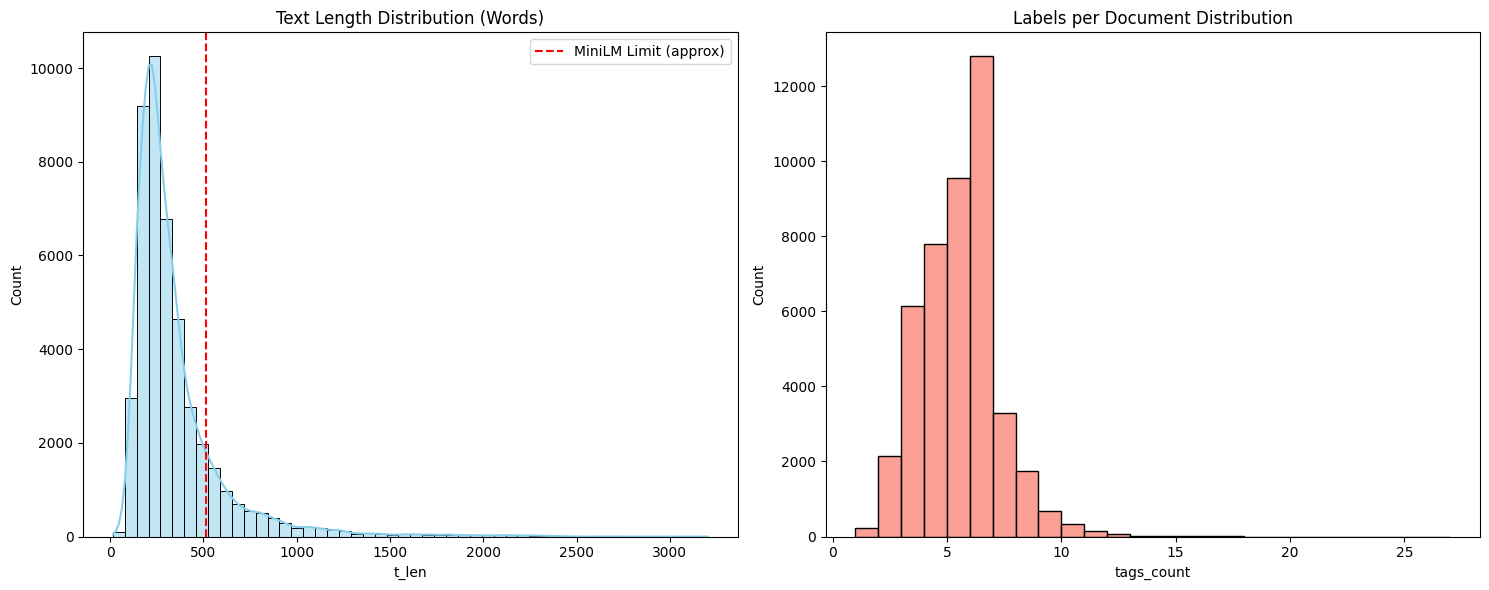

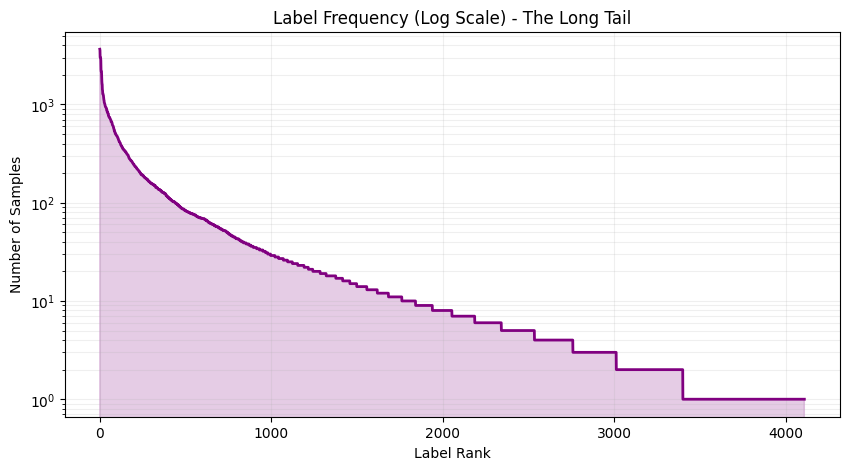

In [147]:
train_labels, train_df = eda(train_df, "result/eurlex/train_processed")


==================== DATASET STATS ====================
             t_len      til_len        r_len        h_len        m_len  \
count  6000.000000  6000.000000  6000.000000  6000.000000  6000.000000   
mean    346.879167    32.909167   313.970000    43.025500   178.956167   
std     261.393738    11.392229   259.694495    13.670552   253.004303   
min      43.000000     1.000000    19.000000    10.000000     5.000000   
25%     200.000000    24.000000   167.000000    34.000000    56.000000   
50%     272.000000    31.000000   235.000000    41.000000    86.000000   
75%     392.000000    39.000000   357.000000    50.000000   171.250000   
max    2405.000000   147.000000  2380.000000   311.000000  2447.000000   

        tags_count  
count  6000.000000  
mean      5.059333  
std       1.736754  
min       1.000000  
25%       4.000000  
50%       5.000000  
75%       6.000000  
max      19.000000  

Unique labels found in data: 2517
--> Frequent labels (>50 samples): 132
--> Few-shot 

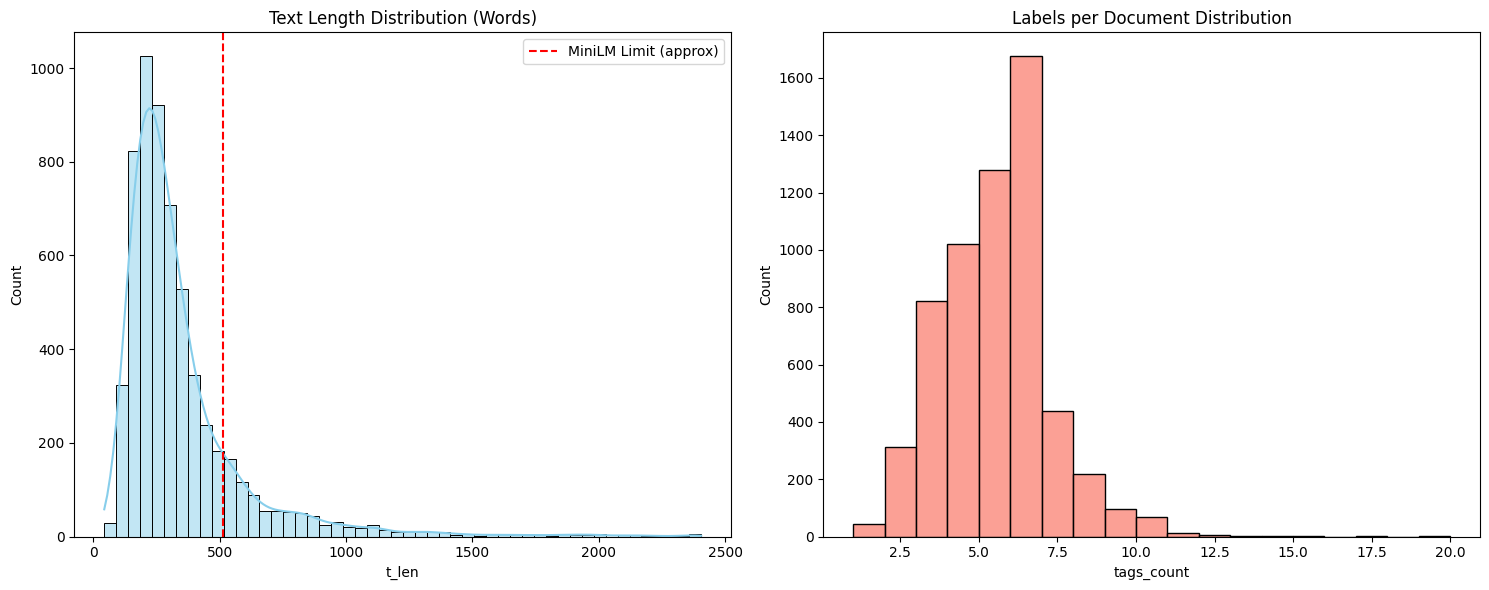

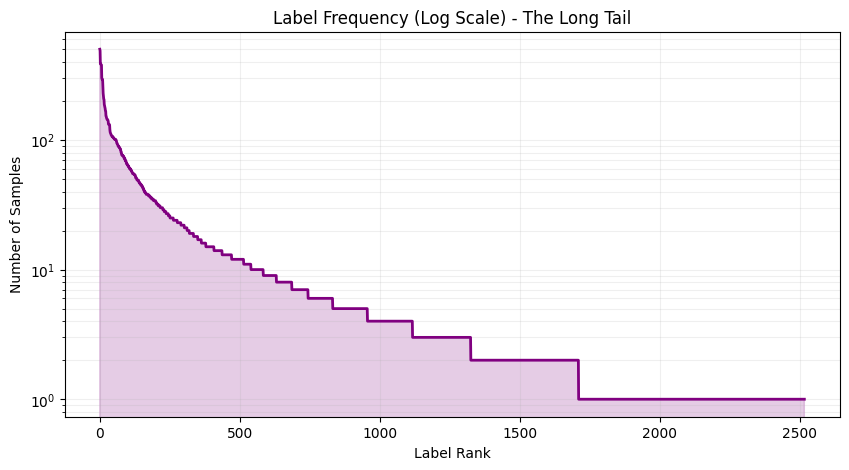

In [148]:
test_labels, test_df = eda(test_df, "result/eurlex/test_processed")

# Phase 3: Training LSTM

## I. Set up

### 1. Embedding

#### Precomputed 

In [40]:
from datasets import load_dataset

ds = load_dataset("pietrolesci/eurlex-57k", "embedding_all-MiniLM-L12-v2")
print(ds)

DatasetDict({
    train: Dataset({
        features: ['uid', 'embedding_all-MiniLM-L12-v2'],
        num_rows: 45000
    })
    validation: Dataset({
        features: ['uid', 'embedding_all-MiniLM-L12-v2'],
        num_rows: 6000
    })
    test: Dataset({
        features: ['uid', 'embedding_all-MiniLM-L12-v2'],
        num_rows: 6000
    })
})


In [22]:
train_df.head(1)

,celex_id,document_type,title,header,recitals,main_body,eurovoc_concepts,text,uid,t_len,tags,tags_count,tag_names,filtered_tags,l1,l1_name
0,32014R0727,Regulation,commission implementing regulation (eu) no 727...,1.7.2014 EN Official Journal of the European U...,", having regard to the treaty on the functioni...",a review of implementing regulation (eu) no 13...,['1402' '2771' '3191' '5055' '519' '5969' '5971'],commission implementing regulation (eu) no 727...,0,1755,['1402' '2771' '3191' '5055' '519' '5969' '5971'],7,['1402' '2771' '3191' '5055' '519' '5969' '5971'],['1402' '2771' '3191' '5055' '519' '5969' '5971'],"[5, 11]","['3842', '3483']"


#### Self Embedding

In [ ]:
import torch
import pandas as pd
from sentence_transformers import SentenceTransformer

# This is for LSTM only, so we will use the same embedding model 
class EmbeddingExtractor:
    def __init__(self, model_name='sentence-transformers/all-MiniLM-L12-v2', device=None):
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = SentenceTransformer(model_name).to(self.device)
        self.dim = 384 
        

    def extract(self, df, batch_size=64, save_path=None):
        texts = df['text'].tolist()
        if len(texts) < 5000:
            print(f"Warning: Dataset size ({len(texts)}) is below the assignment requirement.")
        else:
            print(f"Extracting embeddings for {len(texts)} samples...")
        embeddings = self.model.encode(
            texts,
            batch_size=batch_size,
            show_progress_bar=True,
            convert_to_tensor=True,
            device=self.device
        )
        
        if save_path:
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            torch.save(embeddings.cpu(), save_path)
            print(f"Embeddings saved to {save_path}. Dimension: {self.dim}")
            
        return embeddings

    @staticmethod
    def load_embeddings(path = 'data/eurlex/train.pt'):
        if os.path.exists(path):
            return torch.load(path)
        raise FileNotFoundError(f"No embeddings found at {path}")

extractor = EmbeddingExtractor()
# embeddings = extractor.extract(df, save_path='data/cs_embeddings.pt')
# embeddings = extractor.load_embeddings(path='data/cs_embeddings.pt')

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/352 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### 2. LSTM class 
- Inherit from torch.nn library
- Add head manually at will 
- Use Bidirection LSTM for more context coverage

Attention Head: We know that deep neural network suffers from gradient vanishing. Self Attention capture and reenforce gradient of core concepts. 

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

class SelfAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(SelfAttention, self).__init__()
        self.projection = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, encoder_outputs):
        energy = self.projection(encoder_outputs)
        weights = F.softmax(energy.squeeze(-1), dim=1)
        outputs = (encoder_outputs * weights.unsqueeze(-1)).sum(dim=1)
        return outputs, weights



Bidirectional LSTM: Using Dual-context Capture, better in getting the semantic of key context, esspecially in our real life dataset, mixing of Nature Language questions and statements

In [ ]:
class BiLSTM(nn.Module):
    def __init__(self, input_dim=384, hidden_dim=128, dropout=0.3):
        super(BiLSTM, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attention = SelfAttention(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.heads = nn.ModuleDict()

    def add_head(self, name, num_classes):
        self.heads[name] = nn.Linear(self.hidden_dim * 2, num_classes)
        return self

    def forward(self, x, head_names=None):
        x = x.float()
        if x.dim() == 2: x = x.unsqueeze(1)
        lstm_out, _ = self.lstm(x)
        context_vector, attn_weights = self.attention(lstm_out)
        context_vector = self.dropout(context_vector)
        
        results = {'attention': attn_weights}
        target_heads = head_names if head_names else self.heads.keys()
        for name in target_heads:
            if name in self.heads:
                results[name] = self.heads[name](context_vector)
        return results
    @staticmethod
    def load_model(path, heads_config, device='cpu', input_dim=384, hidden_dim=128):
        model = BiLSTM(input_dim=input_dim, hidden_dim=hidden_dim)
        
        for name, num_classes in heads_config.items():
            model.add_head(name, num_classes)
            
        checkpoint = torch.load(path, map_location=device)
        state_dict = checkpoint.get('model_state', checkpoint)
        
        try:
            model.load_state_dict(state_dict, strict=False)
            model.to(device)
            model.eval()
            print(f"Successfully loaded weights from {path}")
        except RuntimeError as e:
            print(f"Error: {e}")
            
        return model

'''
# Well I cannot cluster labels in this dataset, so i use flat labels (only l3). 
# Those code are not used in the final submission, but I keep them here for reference and future work on hierarchical classification.
class MultiLayerDataset(Dataset):
    def __init__(self, embeddings, l1_multihot, l2_labels, l3_multihot):
        self.x = embeddings
        self.y = {
            'l1': torch.tensor(l1_multihot, dtype=torch.float),
            'l2': torch.tensor(l2_labels, dtype=torch.float),
            'l3': torch.tensor(l3_multihot, dtype=torch.float)
        }

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], {name: label[idx] for name, label in self.y.items()}

class MultiTaskLoss(nn.Module):
    def __init__(self, weights=None):
        super(MultiTaskLoss, self).__init__()
        self.weights = weights if weights else {'l1': 0.1, 'l2': 0.3, 'l3': 0.6}
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, predictions, targets):
        total_loss = 0
        loss_dict = {}
        for name, pred in predictions.items():
            if name == 'attention' or name not in targets: continue
            loss = self.bce_loss(pred, targets[name].float())
            w = self.weights.get(name, 1.0)
            total_loss += w * loss
            loss_dict[f'loss_{name}'] = loss.item()
        return total_loss, loss_dict
'''


### 3. Dataload and split

In [50]:
from sklearn.preprocessing import MultiLabelBinarizer
import torch
from torch.utils.data import TensorDataset, DataLoader
from skmultilearn.model_selection import IterativeStratification
from sklearn.metrics import f1_score, hamming_loss
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from tqdm import tqdm
import pandas as pd
import joblib

train_df = pd.read_csv('data/eurlex/train_processed.csv')
test_df = pd.read_csv('data/eurlex/test_processed.csv')

tags = train_df['filtered_tags'].apply(clean_tags)

train_df['filtered_tags'] = train_df['filtered_tags'].apply(clean_tags)
test_df['filtered_tags'] = test_df['filtered_tags'].apply(clean_tags)

mlb = MultiLabelBinarizer()
lstm_tags = set()
for tags in train_tags:
    lstm_tags.update(tags)



mlb.fit([list(lstm_tags)])
print("Sample classes:", mlb.classes_[-10:])
print("Number of classes:", len(mlb.classes_))


joblib.dump(mlb, 'data/eurlex/mlb_lstm.pkl')
def check_alignment(dataset_split, df):
    uids_ds = set(dataset_split['uid'])
    uids_df = set(df['uid'])
    if uids_ds != uids_df:
        print(f"UID mismatch detected! DS UIDs: {len(uids_ds)}, DF UIDs: {len(uids_df)}")
        print(f"UIDs in DS but not in DF: {len(uids_ds - uids_df)}")
        print(f"UIDs in DF but not in DS: {len(uids_df - uids_ds)}")
    else:
        print("=====================")
        print("UIDs are perfectly aligned between dataset and DataFrame.")
        return dataset_split, df, dataset_split['uid']
    
    common_uids = uids_ds.intersection(uids_df)
    dataset_split = dataset_split.filter(lambda x: x['uid'] in common_uids)
    df = df[df['uid'].isin(common_uids)].copy()
    return check_alignment(dataset_split, df)

def prepare_loader(split_name, dataset_dict, df, batch_size=128, shuffle=False):
    ds_split = dataset_dict[split_name]
    uids = ds_split['uid']
    ds_split, df ,uids  = check_alignment(ds_split, df)  
    print("==============================================")
    print("Prepare Loader for split:", split_name)
    x_tensor = torch.tensor(np.array(ds_split['embedding_all-MiniLM-L12-v2']), dtype=torch.float32)
    

    meta_indexed = df.set_index('uid')
    relevant_tags = meta_indexed.loc[uids]['filtered_tags']
    print("Debug", relevant_tags.head(5))
    y_tensor = torch.tensor(mlb.transform(relevant_tags), dtype=torch.float32)
    
    return DataLoader(TensorDataset(x_tensor, y_tensor), batch_size=batch_size, shuffle=shuffle)




Sample classes: ['99' '990' '993' '994' '995' '996' '997' '998' '999' 'c_871b5612']
Number of classes: 4108


In [ ]:
train_loader = prepare_loader('train', ds, train_df, batch_size=128, shuffle=True)
test_loader = prepare_loader('test', ds, test_df, batch_size=128, shuffle=False)

print(f"--- DATA READY (Original Split) ---")
print(f"Train: {len(train_loader.dataset)} | Test: {len(test_loader.dataset)}")

### 4. Loss

In [22]:
import torch.nn.functional as F
import torch
from torch import nn
def get_cb_weights(df, mlb, beta=0.999):
    """
    A simple weight assigning formula: W = (1 - beta)/(1 - beta^n)
    Satisfy: f'(x1) < f'(x2)
    """
    df['tags'] = df['tags'].apply(clean_tags)
    tag_counts = df['tags'].explode().value_counts()
    
    
    samples_per_class = np.array([tag_counts.get(cls, 0) for cls in mlb.classes_])
    
    e = 1.0 - np.power(beta, samples_per_class)
    
    weights = (1.0 - beta) / np.where(e == 0, 0.01, e)
    
    #weights = weights / np.sum(weights) * len(mlb.classes_)
    #weights = np.power(weights, 0.67)
    weights = weights / np.min(weights) # Normalize: min_weight = min_weight/min_weight = 1
    
    print(f"--> Min Weight (Head): {np.min(weights):.4f}")
    print(f"--> Max Weight (Tail): {np.max(weights):.4f}")
    print(f"--> Average Weight: {np.average(weights):.4f}")
    return torch.tensor(weights, dtype=torch.float)

class ASLCB(nn.Module):
    def __init__(self, gamma_neg=2, gamma_pos=0.0, clip=0.05, cb_weights=None):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.cb_weights = cb_weights # Tensor (662,)

    def forward(self, x, y):
        # x: logits, y: targets
        xs_pos = torch.sigmoid(x)
        xs_neg = 1 - xs_pos

        # Asymmetric Clipping
        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        # Basic BCE
        loss_pos = y * torch.log(xs_pos.clamp(min=1e-7))
        loss_neg = (1 - y) * torch.log(xs_neg.clamp(min=1e-7))
        loss = - (loss_pos + loss_neg)

        # Asymmetric Focusing
        final_weight = torch.where(y > 0.5, 
                                   torch.pow(1 - xs_pos, self.gamma_pos), 
                                   torch.pow(1 - xs_neg, self.gamma_neg))
        loss *= final_weight

        # Apply Class-Balanced weights
        if self.cb_weights is not None:
            loss *= self.cb_weights.to(x.device)

        return loss.mean()

## II. Training

### 1. Init optimizer

In [ ]:
import torch.optim as optim
from sklearn.metrics import f1_score, hamming_loss
import numpy as np
from tqdm import tqdm

# Config
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(mlb.classes_)
print(f"Device: {dev} | Number of Classes: {num_classes}")

# Model Init
model = BiLSTM(input_dim=384, hidden_dim=256).add_head('l3', num_classes)
model.to(dev)

# Loss & Optimizer
opt = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

weights = get_cb_weights(train_df, mlb, beta=0.999).to(dev) # Keep it moderate since lSTM is dangerous with high weights
crit_base = nn.BCEWithLogitsLoss(pos_weight = torch.tensor([100.0]).to(dev))
crit_cb = torch.nn.BCEWithLogitsLoss(pos_weight=weights)


Device: cuda | Number of Classes: 4108
--> Min Weight (Head): 1.0000
--> Max Weight (Tail): 973.9262
--> Average Weight: 289.4367


### 2. Implement training epoch with tracking bars

In [84]:
import torch.optim as optim
from sklearn.metrics import f1_score, hamming_loss
import numpy as np
from tqdm import tqdm
from torch.amp import GradScaler, autocast

def train_epoch(model,num_classes, loader, optimizer, criterion, device, save_mem=True):
    model.train()
    epoch_loss = 0

    tp_sum = torch.zeros(num_classes).to(device)
    fp_sum = torch.zeros(num_classes).to(device)
    fn_sum = torch.zeros(num_classes).to(device)
    
    hm_mismatch = 0
    total = 0

    scaler = GradScaler()
    pbar = tqdm(loader, desc="Training Batch", leave=True)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        
        # Forward & Backward
        if save_mem:
            with autocast(device_type=device.type):
                outputs = model(x, head_names=['l3'])['l3']
                loss = criterion(outputs, y)
            
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(x, head_names=['l3'])['l3']
            loss = criterion(outputs, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()
        
        epoch_loss += loss.item()
        
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
        with torch.no_grad():
            preds = (torch.sigmoid(outputs) > 0.5).float()

            mismatches = (preds != y).sum().item() 
            hm_mismatch += mismatches
            total += y.numel()

            tp_sum += (preds * y).sum(dim=0)
            fp_sum += (preds * (1 - y)).sum(dim=0)
            fn_sum += ((1 - preds) * y).sum(dim=0)


    hm_loss = hm_mismatch / total
    f1_class = (2 * tp_sum) / (2 * tp_sum + fp_sum + fn_sum + 1e-8)
    macro_f1 = f1_class.mean().item()
    
    return {
        'loss': epoch_loss / len(loader),
        'f1': macro_f1,
        'hamming': hm_loss
    }

def full_training(model, mlb : MultiLabelBinarizer,loader, optimizer, criterion, device, epochs=30, name = 'lstm_attention.pt', save_mem = True): # a training function with simplified status tracking
    print(f"--- Starting Training on {device} ---")
    for epoch in range(epochs):
        metrics = train_epoch(model, len(mlb.classes_), loader, optimizer, criterion, device, save_mem=save_mem)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Loss: {metrics['loss']:.4f} | "
              f"Macro-F1: {metrics['f1']:.4f} | "
              f"Hamming: {metrics['hamming']:.4f}")
    folder = "model/weight/"
    os.makedirs(folder, exist_ok=True)
    path = folder + name
    torch.save(model.state_dict(), path)
    print(f"Model saved to {path}" )

    return model




In [63]:
lstm_base = full_training(model, mlb, train_loader, opt, crit_base, dev, epochs=100, name = 'lstm_attention_bce.pt')

--- Starting Training on cuda ---


Training Batch: 100%|██████████| 352/352 [00:04<00:00, 86.05it/s, loss=0.0642]


Epoch 01/100 | Loss: 0.0617 | Macro-F1: 0.1574 | Hamming: 0.0098


Training Batch: 100%|██████████| 352/352 [00:03<00:00, 90.86it/s, loss=0.0551]


Epoch 02/100 | Loss: 0.0579 | Macro-F1: 0.2041 | Hamming: 0.0094


...

Epoch 98/100 | Loss: 0.0191 | Macro-F1: 0.6444 | Hamming: 0.0042


Training Batch: 100%|██████████| 352/352 [00:04<00:00, 80.08it/s, loss=0.0170]


Epoch 99/100 | Loss: 0.0190 | Macro-F1: 0.6452 | Hamming: 0.0042


Training Batch: 100%|██████████| 352/352 [00:04<00:00, 84.18it/s, loss=0.0267]


Epoch 100/100 | Loss: 0.0191 | Macro-F1: 0.6458 | Hamming: 0.0042
Model saved to model/weight/lstm_attention_bce.pt


In [67]:
model = BiLSTM(input_dim=384, hidden_dim=256).add_head('l3', num_classes)
model.to(dev)
opt = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

lstm_cb = full_training(model, mlb, train_loader, opt, crit_cb, dev, epochs=100, name = 'lstm_attention_cb.pt')

--- Starting Training on cuda ---


Training Batch: 100%|██████████| 352/352 [00:04<00:00, 83.25it/s, loss=0.0858]


Epoch 01/100 | Loss: 0.1376 | Macro-F1: 0.0006 | Hamming: 0.0053


Training Batch: 100%|██████████| 352/352 [00:03<00:00, 88.85it/s, loss=0.1011]


Epoch 02/100 | Loss: 0.0996 | Macro-F1: 0.0000 | Hamming: 0.0012


...

Epoch 98/100 | Loss: 0.0061 | Macro-F1: 0.6738 | Hamming: 0.0012


Training Batch: 100%|██████████| 352/352 [00:03<00:00, 96.25it/s, loss=0.0055]


Epoch 99/100 | Loss: 0.0061 | Macro-F1: 0.6751 | Hamming: 0.0012


Training Batch: 100%|██████████| 352/352 [00:03<00:00, 96.09it/s, loss=0.0061]


Epoch 100/100 | Loss: 0.0061 | Macro-F1: 0.6771 | Hamming: 0.0012
Model saved to model/weight/lstm_attention_cb.pt


In [ ]:
weights = get_cb_weights(train_df, mlb, beta=0.999) # LSTM gradients might vanish with tail tags so keep the weights a little high, with gradient normalization to avoid gradient explosion.
crit_aslcb = ASLCB(gamma_neg=3, gamma_pos=0.5, clip=0.05, cb_weights=weights)
model = BiLSTM(input_dim=384, hidden_dim=256).add_head('l3', num_classes)
model.to(dev)
opt = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
lstm_aslcb = full_training(model, mlb,train_loader, opt, crit_aslcb, dev, epochs=100, name = 'lstm_attention_aslcb.pt')

--> Min Weight (Head): 1.0000
--> Max Weight (Tail): 973.9262
--> Average Weight: 289.4367
--- Starting Training on cuda ---


Training Batch: 100%|██████████| 352/352 [00:04<00:00, 73.47it/s, loss=0.0427]


Epoch 01/100 | Loss: 0.5939 | Macro-F1: 0.0007 | Hamming: 0.0055


Training Batch: 100%|██████████| 352/352 [00:04<00:00, 77.56it/s, loss=0.0556]


Epoch 02/100 | Loss: 0.0471 | Macro-F1: 0.0002 | Hamming: 0.0012


...

Epoch 98/100 | Loss: 0.0079 | Macro-F1: 0.7450 | Hamming: 0.0015


Training Batch: 100%|██████████| 352/352 [00:04<00:00, 80.80it/s, loss=0.0075]


Epoch 99/100 | Loss: 0.0066 | Macro-F1: 0.8061 | Hamming: 0.0011


Training Batch: 100%|██████████| 352/352 [00:04<00:00, 75.59it/s, loss=0.0061]


Epoch 100/100 | Loss: 0.0070 | Macro-F1: 0.7840 | Hamming: 0.0013
Model saved to model/weight/lstm_attention_aslcb.pt


### 3. Comprehensive evaluation

#### Classification metrics:
- Accuracy: Exact Match Ratio. Expected to be low since it counts via samples, not tags
- Precision: Show how many predicted labels are actually correct
- Recall: Show how many of the actual correct labels were guessed
- F1-Score: balances the trade-off between missing labels and over-predicting

#### Multilabel metrics:
- Hamming Loss: The ratio of the total number of labels that are incorrectly predicted
- nDCG@k: Normalized Discounted Cumulative Gain, rewarding the correct labels the higher they are on the ranked list.

In [ ]:
import numpy as np
import torch
from tqdm import tqdm
from sklearn.metrics import classification_report, hamming_loss, ndcg_score, f1_score
from tabulate import tabulate
import os
import pandas as pd
from torch.amp import autocast


def precision_at_k(y_true, y_score, k=5):
    order = np.argsort(y_score, axis=1)[:, ::-1]
    top_k = order[:, :k]
    hits = np.take_along_axis(y_true, top_k, axis=1)
    return np.mean(np.sum(hits, axis=1) / k)

def recall_at_k(y_true, y_score, k=5):
    order = np.argsort(y_score, axis=1)[:, ::-1]
    top_k = order[:, :k]
    hits = np.take_along_axis(y_true, top_k, axis=1)
    relevant = np.sum(y_true, axis=1)
    recall = np.sum(hits, axis=1) / np.maximum(relevant, 1)
    return np.mean(recall)

def eval(model, loader, mlb, device, train_counter, test_counter, thres=0.3, active_head='l3', fs_thresh=10, filename="result/report.csv"):
    model.eval()
    all_scores, all_targets = [], []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Predicting"):
            if active_head == 'l3':
                x = [(batch[j].to(device).long(), batch[j+1].to(device).long()) 
                     for j in range(0, len(batch) - 1, 2)]
            else:
                x = batch[0].to(device).long()
            y = batch[-1].to(device).long()
            with autocast(device_type='cuda'):
                out = model(x, active_head=active_head)
                outputs = out[active_head] if isinstance(out, dict) else out
                
            all_scores.append(torch.sigmoid(outputs).cpu().numpy())
            all_targets.append(y.cpu().numpy())
            
    y_score = np.vstack(all_scores)
    y_true = np.vstack(all_targets)
    y_pred = (y_score > thres).astype(int)
    
    pk = {f"P@{k}": precision_at_k(y_true, y_score, k=k) for k in [1, 3, 5]}
    rk = {f"R@{k}": recall_at_k(y_true, y_score, k=k) for k in [1, 3, 5]}
    ndcg_5 = ndcg_score(y_true, y_score, k=5)
    
    report_dict = classification_report(y_true, y_pred, target_names=mlb.classes_, output_dict=True, zero_division=0)
    
    name2idx = {name: i for i, name in enumerate(mlb.classes_)}
    cat_metrics = []
    label_groups = {"Zero-shot": [], "Few-shot": [], "Normal": []}
    
    for label in test_counter.keys():
        train_freq = train_counter.get(label, 0)
        label_str = str(label)
        if label_str not in name2idx: continue
        
        if train_freq == 0:
            label_groups["Zero-shot"].append(label_str)
        elif train_freq < fs_thresh:
            label_groups["Few-shot"].append(label_str)
        else:
            label_groups["Normal"].append(label_str)

    for group_name, labels in label_groups.items():
        if not labels:
            cat_metrics.append([group_name, 0, 0, 0, 0, 0, 0, 0])
            continue
            
        idxs = [name2idx[l] for l in labels]
        group_true = y_true[:, idxs]
        group_pred = y_pred[:, idxs]
        
        tp = np.sum((group_true == 1) & (group_pred == 1))
        fp = np.sum((group_true == 0) & (group_pred == 1))
        fn = np.sum((group_true == 1) & (group_pred == 0))
        
        micro_p = tp / (tp + fp) if (tp + fp) > 0 else 0
        micro_r = tp / (tp + fn) if (tp + fn) > 0 else 0
        micro_f1 = 2 * micro_p * micro_r / (micro_p + micro_r) if (micro_p + micro_r) > 0 else 0
        
        macro_p = np.mean([report_dict[l]['precision'] for l in labels])
        macro_r = np.mean([report_dict[l]['recall'] for l in labels])
        macro_f1 = np.mean([report_dict[l]['f1-score'] for l in labels])
        support = np.sum(group_true)
        
        cat_metrics.append([
            group_name, 
            f"{macro_f1:.4f}", f"{micro_f1:.4f}", 
            f"{macro_p:.4f}", f"{micro_p:.4f}", 
            f"{macro_r:.4f}", f"{micro_r:.4f}", 
            int(support)
        ])

    metrics_to_show = ['micro avg', 'macro avg', 'weighted avg']
    global_data = [[m.upper()] + [report_dict[m][k] for k in ['precision', 'recall', 'f1-score', 'support']] for m in metrics_to_show]
    basic_tab = tabulate(global_data, headers=['GLOBAL', 'PREC', 'RECALL', 'F1', 'SUPPORT'], tablefmt='fancy_grid')
    
    xmc_data = [
        ["P@1 / P@3 / P@5", f"{pk['P@1']:.4f} / {pk['P@3']:.4f} / {pk['P@5']:.4f}"],
        ["R@1 / R@3 / R@5", f"{rk['R@1']:.4f} / {rk['R@3']:.4f} / {rk['R@5']:.4f}"],
        ["nDCG@5", f"{ndcg_5:.4f}"],
        ["Hamming Loss", f"{hamming_loss(y_true, y_pred):.5f}"]
    ]
    extra_tab = tabulate(xmc_data, headers=['XMC METRIC', 'VALUE'], tablefmt='fancy_grid')
    
    cat_headers = ['CATEGORY', 'MA-F1', 'MI-F1', 'MA-PREC', 'MI-PREC', 'MA-REC', 'MI-REC', 'SUPPORT']
    cat_tab = tabulate(cat_metrics, headers=cat_headers, tablefmt='fancy_grid')

    df_report = pd.DataFrame(report_dict).transpose()
    for k, v in {**pk, **rk, "ndcg@5": ndcg_5}.items():
        df_report.loc[k] = [v] * 3 + [y_true.shape[0]]
        
    if filename:
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        df_report.to_csv(filename, index=True, encoding='utf-8-sig')
    
    return df_report, basic_tab, extra_tab, cat_tab

In [132]:
rep, basic, extra, cat = eval(lstm_base, test_loader, mlb, dev, train_labels, test_labels, thres=0.9, filename="result/eurlex/lstm_base_report.csv")
print("======================== Fundamental Metric for classification ========================")
print(basic)
print("===================== Addtional Metric for Multilabel classification =====================")
print(extra)

Predicting: 100%|██████████| 47/47 [00:00<00:00, 223.92it/s]


======================== Fundamental Metric for classification ========================
╒══════════════╤══════════╤══════════╤══════════╤═══════════╕
│ GLOBAL       │     PREC │   RECALL │       F1 │   SUPPORT │
╞══════════════╪══════════╪══════════╪══════════╪═══════════╡
│ MICRO AVG    │ 0.448086 │ 0.794812 │ 0.573086 │     30260 │
├──────────────┼──────────┼──────────┼──────────┼───────────┤
│ MACRO AVG    │ 0.237093 │ 0.301765 │ 0.248822 │     30260 │
├──────────────┼──────────┼──────────┼──────────┼───────────┤
│ WEIGHTED AVG │ 0.510808 │ 0.794812 │ 0.601139 │     30260 │
╘══════════════╧══════════╧══════════╧══════════╧═══════════╛
===================== Addtional Metric for Multilabel classification =====================
╒═════════════════╤══════════════════════════╕
│ XMC METRIC      │ VALUE                    │
╞═════════════════╪══════════════════════════╡
│ P@1 / P@3 / P@5 │ 0.8577 / 0.7371 / 0.6152 │
├─────────────────┼──────────────────────────┤
│ R@1 / R@3 / R@5 │ 0.1946 /

In [133]:
print("===================== Category-wise Metric for Multilabel classification =====================")
print(cat)

===================== Category-wise Metric for Multilabel classification =====================
╒════════════╤═════════╤═════════╤═══════════╤═══════════╤══════════╤══════════╤═══════════╕
│ CATEGORY   │   MA-F1 │   MI-F1 │   MA-PREC │   MI-PREC │   MA-REC │   MI-REC │   SUPPORT │
╞════════════╪═════════╪═════════╪═══════════╪═══════════╪══════════╪══════════╪═══════════╡
│ Zero-shot  │  0      │  0      │    0      │    0      │   0      │   0      │         0 │
├────────────┼─────────┼─────────┼───────────┼───────────┼──────────┼──────────┼───────────┤
│ Few-shot   │  0.2447 │  0.3521 │    0.272  │    0.5841 │   0.2442 │   0.252  │      1020 │
├────────────┼─────────┼─────────┼───────────┼───────────┼──────────┼──────────┼───────────┤
│ Normal     │  0.4931 │  0.5795 │    0.4538 │    0.4499 │   0.6198 │   0.8137 │     29240 │
╘════════════╧═════════╧═════════╧═══════════╧═══════════╧══════════╧══════════╧═══════════╛


In [118]:
rep, basic, extra, cat = eval(lstm_cb, test_loader, mlb, dev,train_labels, test_labels, thres=0.8, filename="result/eurlex/lstm_cb_report.csv")
print('\n')
print("======================== Fundamental Metric for classification ========================")
print(basic)
print('\n')
print("===================== Addtional Metric for Multilabel classification =====================")
print(extra)
print('\n')


Predicting: 100%|██████████| 47/47 [00:00<00:00, 243.86it/s]




======================== Fundamental Metric for classification ========================
╒══════════════╤══════════╤══════════╤══════════╤═══════════╕
│ GLOBAL       │     PREC │   RECALL │       F1 │   SUPPORT │
╞══════════════╪══════════╪══════════╪══════════╪═══════════╡
│ MICRO AVG    │ 0.708592 │ 0.539921 │ 0.612863 │     30260 │
├──────────────┼──────────┼──────────┼──────────┼───────────┤
│ MACRO AVG    │ 0.27828  │ 0.272888 │ 0.258013 │     30260 │
├──────────────┼──────────┼──────────┼──────────┼───────────┤
│ WEIGHTED AVG │ 0.748001 │ 0.539921 │ 0.588995 │     30260 │
╘══════════════╧══════════╧══════════╧══════════╧═══════════╛


===================== Addtional Metric for Multilabel classification =====================
╒═════════════════╤══════════════════════════╕
│ XMC METRIC      │ VALUE                    │
╞═════════════════╪══════════════════════════╡
│ P@1 / P@3 / P@5 │ 0.8535 / 0.7303 / 0.6050 │
├─────────────────┼──────────────────────────┤
│ R@1 / R@3 / R@5 │ 0.19

In [119]:
print("===================== Category-wise Metric for Multilabel classification =====================")
print(cat)

===================== Category-wise Metric for Multilabel classification =====================
╒════════════╤═════════╤═════════╤═══════════╤═══════════╤══════════╤══════════╤═══════════╕
│ CATEGORY   │   MA-F1 │   MI-F1 │   MA-PREC │   MI-PREC │   MA-REC │   MI-REC │   SUPPORT │
╞════════════╪═════════╪═════════╪═══════════╪═══════════╪══════════╪══════════╪═══════════╡
│ Zero-shot  │  0      │  0      │    0      │    0      │   0      │   0      │         0 │
├────────────┼─────────┼─────────┼───────────┼───────────┼──────────┼──────────┼───────────┤
│ Few-shot   │  0.2688 │  0.3531 │    0.2863 │    0.433  │   0.2858 │   0.298  │      1020 │
├────────────┼─────────┼─────────┼───────────┼───────────┼──────────┼──────────┼───────────┤
│ Normal     │  0.5051 │  0.6292 │    0.5463 │    0.7379 │   0.5336 │   0.5484 │     29240 │
╘════════════╧═════════╧═════════╧═══════════╧═══════════╧══════════╧══════════╧═══════════╛


In [141]:
rep, basic, extra, cat = eval(lstm_aslcb, test_loader, mlb, dev, train_labels, test_labels, thres=0.65, filename="result/eurlex/lstm_aslcb_report.csv")
print('\n')
print("======================== Fundamental Metric for classification ========================")
print(basic)
print('\n')
print("===================== Addtional Metric for Multilabel classification =====================")
print(extra)

Predicting: 100%|██████████| 47/47 [00:00<00:00, 107.81it/s]




======================== Fundamental Metric for classification ========================
╒══════════════╤══════════╤══════════╤══════════╤═══════════╕
│ GLOBAL       │     PREC │   RECALL │       F1 │   SUPPORT │
╞══════════════╪══════════╪══════════╪══════════╪═══════════╡
│ MICRO AVG    │ 0.758423 │ 0.560872 │ 0.644857 │     30260 │
├──────────────┼──────────┼──────────┼──────────┼───────────┤
│ MACRO AVG    │ 0.292025 │ 0.235684 │ 0.246929 │     30260 │
├──────────────┼──────────┼──────────┼──────────┼───────────┤
│ WEIGHTED AVG │ 0.728527 │ 0.560872 │ 0.609192 │     30260 │
╘══════════════╧══════════╧══════════╧══════════╧═══════════╛


===================== Addtional Metric for Multilabel classification =====================
╒═════════════════╤══════════════════════════╕
│ XMC METRIC      │ VALUE                    │
╞═════════════════╪══════════════════════════╡
│ P@1 / P@3 / P@5 │ 0.8893 / 0.7596 / 0.6168 │
├─────────────────┼──────────────────────────┤
│ R@1 / R@3 / R@5 │ 0.20

In [142]:
print('\n')
print("===================== Category-wise Metric for Multilabel classification =====================")
print(cat)



===================== Category-wise Metric for Multilabel classification =====================
╒════════════╤═════════╤═════════╤═══════════╤═══════════╤══════════╤══════════╤═══════════╕
│ CATEGORY   │   MA-F1 │   MI-F1 │   MA-PREC │   MI-PREC │   MA-REC │   MI-REC │   SUPPORT │
╞════════════╪═════════╪═════════╪═══════════╪═══════════╪══════════╪══════════╪═══════════╡
│ Zero-shot  │  0      │  0      │    0      │    0      │   0      │   0      │         0 │
├────────────┼─────────┼─────────┼───────────┼───────────┼──────────┼──────────┼───────────┤
│ Few-shot   │  0.257  │  0.3702 │    0.2809 │    0.6559 │   0.2583 │   0.2578 │      1020 │
├────────────┼─────────┼─────────┼───────────┼───────────┼──────────┼──────────┼───────────┤
│ Normal     │  0.4835 │  0.6559 │    0.5814 │    0.7698 │   0.4561 │   0.5714 │     29240 │
╘════════════╧═════════╧═════════╧═══════════╧═══════════╧══════════╧══════════╧═══════════╛


## III. Finetune

In [ ]:
# Config
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(mlb.classes_)
my_heads = {'l3': 322}

lstm = BiLSTM.load_model(
    path="model/weight/lstm_attention_aslcb.pt", 
    heads_config=my_heads, 
    device=dev,      
    input_dim=384, 
    hidden_dim=256      
)

rep, basic, extra = eval(lstm, test_loader, mlb, dev, thres=0.3)
print('\n')
print("======================== Fundamental Metric for classification ========================")
print(basic)
print('\n')
print("===================== Addtional Metric for Multilabel classification =====================")
print(extra)

Successfully loaded weights from model/weight/lstm_attention.pt


Predicting: 100%|██████████| 120/120 [00:00<00:00, 250.77it/s]




======================== Fundamental Metric for classification ========================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.726398 │ 0.726557 │   0.726478 │     41164 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.817118 │ 0.700365 │   0.730309 │     41164 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.732778 │ 0.726557 │   0.717281 │     41164 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.740363 │ 0.74591  │   0.713258 │     41164 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛


===================== Addtional Metric for Multilabel classification =====================
╒══════════════════╤════════╕
│ Subset Accuracy

In [ ]:
full_training(model, train_loader, opt, crit_aslcb , dev, epochs=30, path = 'model/weight/lstm_attention_aslcb.pt')

#### Epoch 31-60

In [ ]:
rep, basic, extra = eval(lstm, test_loader, mlb, dev,train_labels, test_labels, thres=0.3, filename="result/eurlex/lstm_aslcb_final_report.csv")
print('\n')
print("======================== Fundamental Metric for classification ========================")
print(basic)
print('\n')
print("===================== Addtional Metric for Multilabel classification =====================")
print(extra)

Predicting: 100%|██████████| 120/120 [00:00<00:00, 206.56it/s]




======================== Fundamental Metric for classification ========================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.726398 │ 0.726557 │   0.726478 │     41164 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.817118 │ 0.700365 │   0.730309 │     41164 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.732778 │ 0.726557 │   0.717281 │     41164 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.740363 │ 0.74591  │   0.713258 │     41164 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛


===================== Addtional Metric for Multilabel classification =====================
╒══════════════════╤════════╕
│ Subset Accuracy

# Phase 4: Training Transformer

## I. Set up training

### 1. Attention Heads
XMC (Extreme Multilabel Classification) study proves that transformer models struggle to map the output to a large amount of labels. Traditional methods such as Global Pooling cause lost of information to minority labels, causing Tail Label Vanishing, aka Label Bias (model only optimize popular labels)

To better perform multilabel classification with > 300 classes, we propose label-wise-attention head. Different from self attention which capture semantic relations within itself - text to text semantic within an unit of context (paragraphs, usually), the Label-wise Attention is the Multihead Attention, each head capturing semantic from the text that correlates to the target label (text-label attention block). Those attention head will help the model remains attentive to key features that can relate to a tag, rather than scatter the attention span across a whole long paragraph

Source of references are XR-Transformer, MatchXML and AttentionXML. They are prime candidates for this method (but going through multiphase training since they got > 10k labels). Achieve SOTA in 2021 (AttentionXML), 2022 (XR-Transformer) and 2024 (MatchXML), only arguably exceeded by PRIME in 2025 with Hard Negative Mining method, creating suficient batches of Label-to-Prototype. However, since PRIME uses Triplet Loss, requiring massive training resources and time, I wont apply that for the sake of my computer

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel

class MaxHead(nn.Module):
    def __init__(self, dim, num_labels):
        super().__init__()
        self.fc = nn.Linear(dim, num_labels)

    def forward(self, x):
        x = torch.max(x, dim=1)[0]
        return self.fc(x)

class GlobalAttention(nn.Module):
    def __init__(self, dim, num_labels):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.fc = nn.Linear(dim, num_labels)

    def forward(self, x):
        e = self.proj(x)
        w = F.softmax(e.squeeze(-1), dim=1)
        c = (x * w.unsqueeze(-1)).sum(dim=1)
        return self.fc(c)

class LabelWiseAttention(nn.Module):
    def __init__(self, dim, num_labels):
        super().__init__()
        self.W = nn.Parameter(torch.Tensor(num_labels, dim))
        self.bias = nn.Parameter(torch.Tensor(num_labels))
        nn.init.xavier_uniform_(self.W)
        nn.init.constant_(self.bias, -4.5)

    def forward(self, x):
        # att = x @ W^T -> [B, T, L]
        att = torch.matmul(x, self.W.t())
        
        # att = softmax(att, dim=1)^T -> [B, L, T]
        att = F.softmax(att, dim=1).transpose(1, 2)
        
        # out = att @ x -> [B, L, D]
        out = torch.matmul(att, x)
        
        # logits = sum(out * W, dim=-1) + bias -> [B, L]
        return (out * self.W).sum(dim=-1) + self.bias

### 2. Transformer
- Use all-MiniLM-L6-v2 for lightweight. Future improvement with BERT or RoBERTa are on hold, as referenced from previous SOTA

In [25]:
import torch
import torch.nn as nn
from transformers import AutoModel

from typing import List, Tuple

class Trans(nn.Module):
    def __init__(self, model_name='sentence-transformers/all-MiniLM-L12-v2', device=None):
        super().__init__()
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')
        self.transformer = AutoModel.from_pretrained(model_name)
        self.dim = self.transformer.config.hidden_size
        self.heads = nn.ModuleDict()
        self.to(self.device)

    def add_head(self, name, head_type, num_labels):
        if head_type == 'lwa':
            self.heads[name] = LabelWiseAttention(self.dim, num_labels)
        elif head_type == 'global':
            self.heads[name] = GlobalAttention(self.dim, num_labels)
        elif head_type == 'max':
            self.heads[name] = MaxHead(self.dim, num_labels)
        else:
            raise ValueError(f"Head type {head_type} is not supported!")
        self.heads[name].to(self.device)

    def forward(self, inputs: List[Tuple], active_head='l3'):
        outs = []
        for ids, mask in inputs:
            out = self.transformer(input_ids=ids, attention_mask=mask).last_hidden_state
            outs.append(out)

        lhs = torch.cat(outs, dim=1)
        
        if active_head == 'all':
            return {name: head(lhs) for name, head in self.heads.items()}
        
        return {active_head: self.heads[active_head](lhs)}

    def load_checkpoint(self, path):
        checkpoint = torch.load(path, map_location=self.device, weights_only=False)
        if isinstance(checkpoint, dict) and 'model_state' in checkpoint:
            self.load_state_dict(checkpoint['model_state'])
            thres = checkpoint.get('best_threshold', 0.3)
            f1 = checkpoint.get('f1', checkpoint.get('macro_f1', 0.0))
            print(f"--> [SUCCESS] Loaded Model. Best Threshold: {thres} | Best F1: {f1:.4f}")
            return thres 
        else:
            self.load_state_dict(checkpoint)
            print(f"--> [SUCCESS] Loaded Raw State Dict. Threshold defaults to 0.3")
            return 0.3
        
    @torch.no_grad()
    def semantic_init(self, mlb, tokenizer, head_name='l3',id_to_name=None, normalize = 0.05, init_bias=-2.0,batch_size=64):

        if id_to_name is None:
                label = pd.read_csv('data/eurlex/train_labels.csv')
                id_to_name = dict(zip(label['concept_id'], label['title']))

        label_ids = [str(c) for c in mlb.classes_]
        label_names = [id_to_name.get(cid, cid) for cid in label_ids]

        print(f"--> Convert {len(label_names)} label to text. Eg: {label_names[:3]}")
        self.eval()
        all_label_feats = []
        
        pbar = tqdm(range(0, len(label_names), batch_size), desc=f"Semantic Init [{head_name}]")
        for i in pbar:
            batch = label_names[i:i+batch_size]
            inputs = tokenizer(batch, padding=True, truncation=True, max_length=64, return_tensors='pt').to(self.device)
            
            outputs = self.transformer(**inputs)
            batch_feats = outputs.last_hidden_state[:, 0, :] 
            all_label_feats.append(batch_feats)
            
        semantic_weights = torch.cat(all_label_feats, dim=0) 
        semantic_weights = torch.nn.functional.normalize(semantic_weights, p=2, dim=1)
        
        target_head = self.heads[head_name]
        num_labels, dim = semantic_weights.shape
        found_w = False
        found_b = False
        for name, param in target_head.named_parameters():
            if param.shape == (num_labels, dim):
                param.data = (semantic_weights * normalize).to(param.device)
                found_w = True
                print(f"--> [SUCCESS] Weight into param: {name}")
                
            # Match Bias: 
            elif param.shape == (num_labels,):
                param.data.fill_(init_bias)
                found_b = True
                print(f"--> [SUCCESS] Bias into param: {name}")

        if not (found_w and found_b):
            warning = f"{'Weight' if not found_w else ''}{' and ' if not found_w and not found_b else ''}{'Bias' if not found_b else ''}"
            print(f"--> [WARNING] Init {warning} failed fall back to default")

### 3. DataLoad

#### Prepare classifier

In [26]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MultiLabelBinarizer
from transformers import AutoTokenizer
import pandas as pd

model_ckpt = 'sentence-transformers/all-MiniLM-L12-v2'
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

train_df = pd.read_csv('data/eurlex/train_processed.csv')
test_df = pd.read_csv('data/eurlex/test_processed.csv')

label = pd.read_csv('data/eurlex/train_labels.csv')
id_to_title = dict(zip(label['concept_id'].astype(str), label['title']))

def map_ids_to_titles(tags_list, mapping_dict):
    return [mapping_dict.get(str(t), str(t)) for t in tags_list]

def split_and_tokenize(df, tokenizer, max_len=512):
    chunk1_texts = []
    chunk2_texts = []
    
    for _, row in df.iterrows():
        c1 = f"{row['title']} [SEP] {row['main_body']}" # Chunk 1 = title + main_body
        c2 = f"{row['recitals']}" # Chunk 2 = recitals only (often contains key legal points)
        chunk1_texts.append(c1)
        chunk2_texts.append(c2)
    
    enc1 = tokenizer(chunk1_texts, padding='max_length', truncation=True, max_length=max_len, return_tensors='pt')
    enc2 = tokenizer(chunk2_texts, padding='max_length', truncation=True, max_length=max_len, return_tensors='pt')
    
    return enc1, enc2

mlb = MultiLabelBinarizer()
train_tags = train_df['filtered_tags'].apply(clean_tags)
test_tags = test_df['filtered_tags'].apply(clean_tags)

print("Sample processed tags:", train_tags.head(10))
all_classes = set()
for tags in train_tags:
    all_classes.update(tags)
for tags in test_tags:
    all_classes.update(tags)

all_classes = sorted(list(all_classes))

#mlb = MultiLabelBinarizer(classes=all_classes)
mlb.fit([all_classes])
print(f"Total unique tags: {len(mlb.classes_)}")
print(f"Sample classes: {mlb.classes_[:10]} ... {mlb.classes_[-10:]}")


Sample processed tags: 0    [1402, 2771, 3191, 5055, 519, 5969, 5971]
1                      [2319, 2713, 2938, 693]
2          [3560, 365, 4256, 4261, 4353, 4585]
3         [1091, 3842, 3874, 4110, 4381, 5287]
4         [1026, 1048, 2300, 3653, 4271, 4390]
5           [2081, 239, 2871, 4860, 5573, 893]
6                           [2676, 4472, 6042]
7         [2282, 2437, 2879, 4320, 4790, 5254]
8          [191, 2232, 2415, 3579, 4490, 5100]
9                      [1519, 235, 2783, 3892]
Name: filtered_tags, dtype: object
Total unique tags: 4193
Sample classes: ['10' '1000' '1002' '1004' '1005' '1006' '1007' '1008' '1010' '1011'] ... ['99' '990' '993' '994' '995' '996' '997' '998' '999' 'c_871b5612']


In [27]:
import joblib
joblib.dump(mlb, 'data/eurlex/mlb.pktl')


y_train_raw = mlb.transform(train_df['filtered_tags'].apply(clean_tags))
y_test_raw = mlb.transform(test_df['filtered_tags'].apply(clean_tags))

y_train = torch.tensor(y_train_raw, dtype=torch.float32)
y_test = torch.tensor(y_test_raw, dtype=torch.float32)

train_enc1, train_enc2 = split_and_tokenize(train_df, tokenizer)
test_enc1, test_enc2 = split_and_tokenize(test_df, tokenizer)

train_ds = TensorDataset(
    train_enc1['input_ids'], train_enc1['attention_mask'],
    train_enc2['input_ids'], train_enc2['attention_mask'],
    y_train
)

test_ds = TensorDataset(
    test_enc1['input_ids'], test_enc1['attention_mask'],
    test_enc2['input_ids'], test_enc2['attention_mask'],
    y_test
)

#train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

print(f"Ready: Train {len(train_ds)} | Test {len(test_ds)}")
print(f"Labels: {len(mlb.classes_)}")

Ready: Train 45000 | Test 6000
Labels: 4193


### 4. Training pipeline

In [9]:
import gc 
from sklearn.metrics import classification_report, f1_score
from tabulate import tabulate


def best_thres(model, val_loader, mlb, device, active_head='l3', max_t=0.85):
    model.eval()
    all_probs, all_targets = [], []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Predicting"):
            inputs = [
                (batch[j].to(device).long(), batch[j+1].to(device).long()) 
                for j in range(0, len(batch) - 1, 2)
            ]
            y = batch[-1].numpy()
            
            with autocast(device_type='cuda'):
                outputs = model(inputs, active_head=active_head)[active_head]
            all_probs.append(torch.sigmoid(outputs).cpu().numpy().astype(np.float32))
            all_targets.append(y.astype(np.uint8))
            
    y_probs = np.vstack(all_probs)
    y_true = np.vstack(all_targets)
    
    del all_probs, all_targets
    gc.collect() 
    
    best_t, best_f1 = 0.3, 0
    for t in np.round(np.arange(0.1, max_t + 0.05, 0.05), 2):
        y_pred = (y_probs > t).astype(np.uint8)
        ma_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        
        if ma_f1 > best_f1:
            best_f1, best_t = ma_f1, t
        
        del y_pred
        
    gc.collect() 
    
    report = classification_report(y_true, (y_probs > best_t).astype(np.uint8), 
                                   target_names=mlb.classes_, output_dict=True, zero_division=0)
    
    metrics = ['micro avg', 'macro avg', 'weighted avg', 'samples avg']
    table_data = [[m.upper()] + [report[m][k] for k in ['precision', 'recall', 'f1-score', 'support']] for m in metrics]
    basic_tab = tabulate(table_data, headers=['GLOBAL METRIC', 'PRECISION', 'RECALL', 'F1-SCORE', 'SUPPORT'], tablefmt='fancy_grid')
    
    return best_t, basic_tab, best_f1

In [10]:
import torch, os, gc
from torch.optim import AdamW
from torch.amp import GradScaler, autocast
from tqdm import tqdm

def train_transformer(model, train_loader, val_loader, mlb, device, head_name='l3', epochs=10, criterion=None, train_with_wu=True, acc_steps=2, name="trans_lwa"):
    if criterion is None:
        criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([50.0]).to(device))
    scaler = GradScaler()
    best_f1 = 0.0
    warm_up = max(int(epochs*3/4)+1, 0) if train_with_wu else 0
    print("\n=====================================================================================================================")
    print(f"--- Starting Transformer Training on {device} | Warm-up Epochs: {warm_up} | Finetune Epochs: {epochs - warm_up} ---")

    optimizer = AdamW([
        {'params': model.transformer.parameters(), 'lr': 0.0}, # Mặc định là 0
        {'params': model.heads[head_name].parameters(), 'lr': 1e-3}
    ], weight_decay=0.01)

    for epoch in range(epochs):
        if epoch < warm_up and train_with_wu:
            model.transformer.requires_grad_(False)
            lr_backbone = 0.0
            lr_head = 1e-3
            desc = f"Warmup {epoch+1}/{epochs}"
        else:
            model.transformer.requires_grad_(True)
            lr_backbone = 1e-6
            lr_head = 5e-4
            desc = f"Fine-tune {epoch+1}/{epochs}"

        optimizer.param_groups[0]['lr'] = lr_backbone
        optimizer.param_groups[1]['lr'] = lr_head

        model.train()
        optimizer.zero_grad(set_to_none=True)
        pbar = tqdm(train_loader, desc=desc)
        
        for i, batch in enumerate(pbar):
            batch = [b.to(device) for b in batch]
            inputs_list = [
                (batch[j].long(), batch[j+1].long()) 
                for j in range(0, len(batch) - 1, 2)
            ]
            y = batch[-1].float()

            # Scale back from F32 --> F16 to reduce Mem cost
            with autocast(device_type='cuda'): # We avoid auto cast in LSTM since gradients can be overhead with F16, but for transformer it's more stable with less epochs
                outputs = model(inputs_list, active_head=head_name)[head_name]
                loss = criterion(outputs, y) / acc_steps
            
            scaler.scale(loss).backward()
            
            if (i + 1) % acc_steps == 0 or (i + 1) == len(train_loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

            pbar.set_postfix({'loss': f"{loss.item() * acc_steps:.4f}"})
            del inputs_list, y, outputs, loss

        cur_t, tab, curr_f1 = best_thres(model, val_loader, mlb, device, active_head=head_name)
        print(f"================== Epoch {epoch + 1} | t = {cur_t} ==================")
        print(tab)
        
        if curr_f1 > best_f1:
            best_f1 = curr_f1
            os.makedirs("model/weight/eurlex", exist_ok=True)
            save_path = f"model/weight/eurlex/{name}_{head_name}_best.pt"
            torch.save({
                'model_state': model.state_dict(),
                'best_threshold': cur_t,
                'macro_f1': best_f1
            }, save_path)
            print(f"--> Saved: {save_path} (F1: {best_f1:.4f})")
        else:
            print(f"====> F1: {curr_f1:.4f} (Best: {best_f1:.4f})")
            
        torch.cuda.empty_cache()
        gc.collect()

    return model

## II. Model Implementation

### 1. Traditional Transformer 

A commonly used transformer with MaxHead on top of pretrained model to support classification task

#### Base epoch 1-40

In [15]:
import gc

gc.collect()
torch.cuda.empty_cache()

dev= torch.device('cuda' if torch.cuda.is_available() else 'cpu')
trans_aslcb = Trans(device=dev)



weights = get_cb_weights(train_df, mlb, beta=0.996).to(dev) # Reduce weight to preserve pretrained model generalization (or not, feel free to adjust)

crit_aslcb = ASLCB(gamma_neg=2, # Focus more on hard negative samples to further push the decision boundary, should be under 4
                   gamma_pos=0.5, 
                   clip=0.05, # Prevent over-optimization on negative samples
                    cb_weights=weights # weight to balance weak classes
)
crit_cb = torch.nn.BCEWithLogitsLoss(pos_weight=weights) 


trans_aslcb.add_head(name='l3', head_type='max', num_labels=len(mlb.classes_))
if True:
    trans_aslcb.semantic_init(mlb, tokenizer, head_name='l3', 
                            normalize=1 , # Normalize the weight using weight * normalizer for cautions 
                                                #(depends on data, your gamma params and anything gradent related, you may need much scaling or none at all)
                            init_bias=-3.0, # Set bias to a negative value to prevent large initial loss and encourage gradual learnin
                            batch_size=128
                            )
trans_aslcb = train_transformer(trans_aslcb, train_loader, test_loader, mlb, dev, 
                          epochs=40, 
                          head_name='l3', # Flat label no hierarchy 
                          train_with_wu=True, # Maximum 8 warm up epochs, then unfreeze the backbone (number 8 is just simply conclusion of our empirical experiments, feel free to adjust it)
                          acc_steps=4, # accumulation means a batch is technically 16* 4 = 64 
                          criterion=crit_aslcb, # ASL-CB eliminating negative class dominance and focus on positive samples, with class-balanced weights to further avoid head bias
                          name="trans_aslcb")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--> Min Weight (Head): 1.0000
--> Max Weight (Tail): 249.9999
--> Average Weight: 75.0902
--> Convert 4193 label to text. Eg: ['domestic trade', 'financing', 'long-term financing']


Semantic Init [l3]: 100%|██████████| 33/33 [00:00<00:00, 44.94it/s]


--> [SUCCESS] l3 init label vector done. Shape: torch.Size([4193, 384])

--- Starting Transformer Training on cuda | Warm-up Epochs: 31 | Finetune Epochs: 9 ---


...

================== Epoch 38 | t = 0.5 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.577319 │ 0.709876 │   0.636772 │     30356 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.251139 │ 0.277572 │   0.246426 │     30356 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.605244 │ 0.709876 │   0.632951 │     30356 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.602942 │ 0.729845 │   0.635604 │     30356 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
====> F1: 0.2464 (Best: 0.2468)


Predicting: 100%|██████████| 375/375 [00:31<00:00, 12.03it/s]


================== Epoch 39 | t = 0.45 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.518022 │ 0.739986 │   0.609422 │     30356 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.238994 │ 0.300753 │   0.248127 │     30356 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.567223 │ 0.739986 │   0.623257 │     30356 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.548323 │ 0.759138 │   0.614252 │     30356 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/eurlex/trans_aslcb_l3_best.pt (F1: 0.2481)


Predicting: 100%|██████████| 375/375 [00:30<00:00, 12.23it/s]


================== Epoch 40 | t = 0.5 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.580096 │ 0.712182 │   0.639388 │     30356 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.253952 │ 0.282771 │   0.250847 │     30356 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.607036 │ 0.712182 │   0.634701 │     30356 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.606783 │ 0.731876 │   0.639642 │     30356 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/eurlex/trans_aslcb_l3_best.pt (F1: 0.2508)


In [17]:
# Evaluation of our model

trans_aslcb = Trans(device=dev)
trans_aslcb.add_head(name='l3', head_type='max', num_labels=len(mlb.classes_))
trans_aslcb.load_checkpoint(path = "model/weight/eurlex/trans_aslcb_l3_best.pt")
t, final_tab, f1 = best_thres(trans_aslcb, test_loader, mlb, dev, active_head="l3")
print(f"================== Final with t = {t} ==================")
print(final_tab)
print(f"================== Model f1 = {f1} ==================")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--> [SUCCESS] Loaded Model. Best Threshold: 0.5 | Best F1: 0.2508


Predicting: 100%|██████████| 375/375 [00:31<00:00, 11.87it/s]


================== Final with t = 0.5 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.580096 │ 0.712182 │   0.639388 │     30356 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.253952 │ 0.282771 │   0.250847 │     30356 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.607036 │ 0.712182 │   0.634701 │     30356 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.606783 │ 0.731876 │   0.639642 │     30356 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
================== Model f1 = 0.2508470674011591 ==================


#### LWA Epoch 1-40

In [24]:
# This code runs fine before but for a reason I have to manually load the checkpoint later
import gc

gc.collect()
torch.cuda.empty_cache()
trans_lwa_aslcb = Trans(device=dev)

weights = get_cb_weights(train_df, mlb, beta=0.996).to(dev) # Reduce weight to preserve pretrained model generalization
crit_aslcb = ASLCB(gamma_neg=4, gamma_pos=0.5, clip=0.05, cb_weights=weights)


trans_lwa_aslcb.add_head(name='l3', head_type='lwa', num_labels=len(mlb.classes_))
trans_lwa_aslcb.semantic_init(mlb, tokenizer, head_name='l3', batch_size=64)

trans_lwa_aslcb = train_transformer(trans_lwa_aslcb, train_loader, test_loader, mlb, dev, 
                          epochs=40, 
                          head_name='l3', # Flat label no hierarchy 
                          train_with_wu=True, # Maximum 8 warm up epochs, then unfreeze the backbone (number 8 is just simply conclusion of our empirical experiments, feel free to adjust it)
                          acc_steps=4, # accumulation means a batch is technically 16* 4 = 64 
                          criterion=crit_aslcb, # ASL-CB eliminating negative class dominance and focus on positive samples, with class-balanced weights to further avoid head bias
                          name="trans_lwa_aslcb")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--> Min Weight (Head): 1.0000
--> Max Weight (Tail): 249.9999
--> Average Weight: 75.0902
--> Convert 4193 label to text. Eg: ['domestic trade', 'financing', 'long-term financing']


Semantic Init [l3]: 100%|██████████| 66/66 [00:00<00:00, 69.51it/s]


--> [SUCCESS] Weight into param: W
--> [SUCCESS] Bias into param: bias

--- Starting Transformer Training on cuda | Warm-up Epochs: 31 | Finetune Epochs: 9 ---


Warmup 1/40:   0%|          | 5/2813 [00:00<06:48,  6.88it/s, loss=0.0071]


KeyboardInterrupt: 

In [ ]:
# Evaluation of our model
'''
trans_lwa_aslcb = Trans(device=dev)
trans_lwa_aslcb.add_head(name='l3', head_type='lwa', num_labels=len(mlb.classes_))
trans_lwa_aslcb.load_checkpoint(path = "model/weight/eurlex/trans_lwa_aslcb_l3_best.pt")
'''
t, final_tab, f1 = best_thres(trans_lwa_aslcb, test_loader, mlb, dev, active_head="l3")
print(f"================== Final with t = {t} ==================")
print(final_tab)
print(f"================== Model f1 = {f1} ==================")



## III. Deeper Finetuning

LWA not output only 1 vector like Global Pooling or Max Head, but output n vectors with n = amount of tags (432 in our case). It requires deep training for the LWA to capture semantics of all tags, ultlizing output vectors

Upon viewing previous training results, we load the model to continue 5 more epochs for the model to further understand 432 labels

Though I train with warm-up (necessary with first train), it might be a good idea to turn it of since:
1. At warm-up, learning rate of head is fast, which may make them forget the information gained from last training
2. Fine tuning backnone is much slower, turning off warm up may converge it faster to optimal point

If you see the performance lower, that means LWA is either:
1. Forgetting valuable info, or .....
2. Overfit (When that comes the training breaks when you unfreeze the backbone)
Upon that, stop training and change train_with_wu to False

### 1. LWA_Transformer

#### LWA epoch 41-60

In [26]:
import gc

gc.collect()
torch.cuda.empty_cache()
trans_lwa_aslcb = Trans(device=dev)

weights = get_cb_weights(train_df, mlb, beta=0.996).to(dev) # Reduce weight to preserve pretrained model generalization
crit_aslcb = ASLCB(gamma_neg=4, gamma_pos=0.5, clip=0.05, cb_weights=weights)


trans_lwa_aslcb.add_head(name='l3', head_type='lwa', num_labels=len(mlb.classes_))
trans_lwa_aslcb.load_checkpoint(path = "model/weight/eurlex/trans_lwa_aslcb_l3_best.pt")

trans_lwa_aslcb = train_transformer(trans_lwa_aslcb, train_loader, test_loader, mlb, dev, 
                          epochs=20, 
                          head_name='l3', # Flat label no hierarchy 
                          train_with_wu=True, # Maximum 8 warm up epochs, then unfreeze the backbone (number 8 is just simply conclusion of our empirical experiments, feel free to adjust it)
                          acc_steps=4, # accumulation means a batch is technically 16* 4 = 64 
                          criterion=crit_aslcb, # ASL-CB eliminating negative class dominance and focus on positive samples, with class-balanced weights to further avoid head bias
                          name="trans_lwa_aslcb")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--> Min Weight (Head): 1.0000
--> Max Weight (Tail): 249.9999
--> Average Weight: 75.0902


RuntimeError: Error(s) in loading state_dict for Trans:
	Missing key(s) in state_dict: "heads.l3.W", "heads.l3.bias". 
	Unexpected key(s) in state_dict: "heads.l3.q", "heads.l3.fc.weight", "heads.l3.fc.bias". 

### 2. Base_Transformer

In [53]:
import gc

gc.collect()
torch.cuda.empty_cache()
dev= torch.device('cuda' if torch.cuda.is_available() else 'cpu')

trans_aslcb = Trans(device=dev)



trans_aslcb.add_head(name='l3', head_type='max', num_labels=len(mlb.classes_))
trans_aslcb.load_checkpoint(path = "model/weight/eurlex/trans_aslcb_l3_best.pt")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--> [SUCCESS] Loaded Model. Best Threshold: 0.55 | Best F1: 0.2652


np.float64(0.55)

#### Base Epoch 41-60

In [32]:

dev= torch.device('cuda' if torch.cuda.is_available() else 'cpu')
weights = get_cb_weights(train_df, mlb, beta=0.997).to(dev) # Increase weight to further focus on tail tags

crit_aslcb = ASLCB(gamma_neg=3, # Here i lightly increase all metrics to tr
                   gamma_pos=0.5, 
                   clip=0.05, # Prevent over-optimization on negative samples
                    cb_weights=weights # weight to balance weak classes
)
crit_cb = torch.nn.BCEWithLogitsLoss(pos_weight=weights) 
mlb = joblib.load('data/eurlex/mlb.pktl')

trans_aslcb = Trans(device=dev)
trans_aslcb.add_head(name='l3', head_type='max', num_labels=len(mlb.classes_))
trans_aslcb.load_checkpoint(path = "model/weight/eurlex/trans_aslcb_l3_best.pt")

--> Min Weight (Head): 1.0000
--> Max Weight (Tail): 333.3275
--> Average Weight: 99.3194


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--> [SUCCESS] Loaded Model. Best Threshold: 0.55 | Best F1: 0.2507


np.float64(0.55)

In [35]:
mlb = joblib.load("data/eurlex/mlb.pktl")

rep, basic, extra, cat = eval(trans_aslcb, test_loader, mlb, dev, train_labels, test_labels, thres=0.6, filename="result/eurlex/lstm_aslcb_report.csv")
print('\n')
print("======================== Fundamental Metric for classification ========================")
print(basic)
print('\n')
print("===================== Addtional Metric for Multilabel classification =====================")
print(extra)

Predicting: 100%|██████████| 375/375 [00:32<00:00, 11.59it/s]




======================== Fundamental Metric for classification ========================
╒══════════════╤══════════╤══════════╤══════════╤═══════════╕
│ GLOBAL       │     PREC │   RECALL │       F1 │   SUPPORT │
╞══════════════╪══════════╪══════════╪══════════╪═══════════╡
│ MICRO AVG    │ 0.641838 │ 0.663954 │ 0.652709 │     30356 │
├──────────────┼──────────┼──────────┼──────────┼───────────┤
│ MACRO AVG    │ 0.266759 │ 0.263951 │ 0.247329 │     30356 │
├──────────────┼──────────┼──────────┼──────────┼───────────┤
│ WEIGHTED AVG │ 0.660713 │ 0.663954 │ 0.638322 │     30356 │
╘══════════════╧══════════╧══════════╧══════════╧═══════════╛


===================== Addtional Metric for Multilabel classification =====================
╒═════════════════╤══════════════════════════╕
│ XMC METRIC      │ VALUE                    │
╞═════════════════╪══════════════════════════╡
│ P@1 / P@3 / P@5 │ 0.8810 / 0.7632 / 0.6259 │
├─────────────────┼──────────────────────────┤
│ R@1 / R@3 / R@5 │ 0.20

In [ ]:
print("===================== Addtional Metric for Multilabel classification =====================")
print(cat)